In [76]:
import os
import sys
import glob
import numpy as np
import pandas as pd
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option('display.max_colwidth', 150)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib as mpl
import seaborn as sns
from math import log
from scipy import stats
sns.set_theme()
try:
    from cellacdc import cca_functions
    from cellacdc import myutils
except FileNotFoundError:
    # Check if user has developer version --> add the Cell_ACDC/cellacdc
    # folder to path and import from thre
    sys.path.insert(0, '../cellacdc/')
    from cellacdc import cca_functions
    from cellacdc import myutils

In [77]:
#for computer
overall_df = pd.read_csv(r"Y:\dfs_for_final_code\20231013_20231019_repscombined\final_processed_reps_combined_fluorescence_analysis_dataset.csv")


C:\Users\yagya.chadha\AppData\Local\Temp\ipykernel_20756\4063336030.py:2: DtypeWarning: Columns (30,31,52,116) have mixed types. Specify dtype option on import or set low_memory=False.
  overall_df = pd.read_csv(r"Y:\dfs_for_final_code\20231013_20231019_repscombined\final_processed_reps_combined_fluorescence_analysis_dataset.csv")


In [78]:
complete_cycles = overall_df[overall_df['complete_cycle_sa'] == 1]
display(overall_df.rep.unique())
display(len(complete_cycles.f_pos_cell_id_sa.unique()))

pos_len= 0
for rep in ((overall_df['rep']).unique()):
    rep_df = overall_df[overall_df['rep'] == rep]
    for strain in ((rep_df['strain_sa']).unique()):
        strain_df = rep_df[rep_df['strain_sa'] == strain]
        display(rep, strain, strain_df.Position_n.unique())
        pos_len =pos_len + len(strain_df.Position_n.unique())
display(pos_len)

array([1, 2], dtype=int64)

2128

1

'YCY024_1_WTlabelled'

array(['Position_1', 'Position_2', 'Position_3', 'Position_4',
       'Position_5', 'Position_7'], dtype=object)

...

array(['Position_19', 'Position_20', 'Position_21', 'Position_22',
       'Position_23', 'Position_24'], dtype=object)

2

'YCY038_1_Whi5Bck2doubledel_labelled'

array(['Position_25', 'Position_26', 'Position_27', 'Position_28',
       'Position_29', 'Position_30'], dtype=object)

57

# ***for each complete pre-switch cell cycle, calculate time relative to bud emergence*** 

In [79]:
complete_preswitch_cycles = overall_df[(overall_df['growthmedium_sa'] == "SCD")
                            & (overall_df['cycle_saw_switch_sa'] == False)
                            & (overall_df['complete_cycle_sa'] == True)
                            & (overall_df['relationship_sa'] != "bud")]

complete = []
import warnings

with warnings.catch_warnings(record=True):
    for rep in complete_preswitch_cycles['rep'].unique():
        rep_df = complete_preswitch_cycles[complete_preswitch_cycles['rep'] == rep]
        for cellcycle in rep_df['f_pos_cell_id_sa'].unique():
            cycle_df = rep_df[rep_df['f_pos_cell_id_sa'] == cellcycle]
            cycle_df.sort_values(by=['frame_i'], inplace = True)

            S_df = cycle_df[cycle_df['cell_cycle_stage_sa'] == "S"]
            S_df.sort_values(by=['frame_i'], inplace = True)
            bud_emerg_frame = S_df.frame_i.min() 
            cycle_df['bud_emerg_frame'] = bud_emerg_frame 

            for frame in cycle_df['frame_i'].unique():
                frame_ind = (cycle_df[cycle_df['frame_i'] == frame]).index 
                cycle_df.loc[frame_ind[0], 'frame_rel_to_bud_emergence'] = frame - bud_emerg_frame 

            complete.append(cycle_df)



new_complete_preswitch_cycles_df = pd.concat(complete).reset_index(drop = True)
new_complete_preswitch_cycles_df['time_rel_to_bud_emergence_mins'] = new_complete_preswitch_cycles_df['frame_rel_to_bud_emergence']*3
          
        
        

# ***for pre-switch complete cycles, plot histone cellular amount and whi5 nuclear mean pixel intensity on same plot*** 

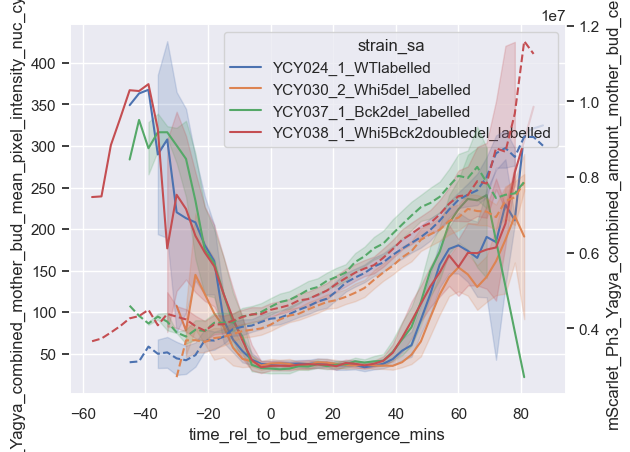

In [80]:
#plot whi5 nuclear intensity

a = sns.lineplot(x = "time_rel_to_bud_emergence_mins", 
                y = "mCitrine_Yagya_combined_mother_bud_mean_pixel_intensity_nuc_cytosubtracted",
                hue = "strain_sa", 
                #kind ="line", 
                data =new_complete_preswitch_cycles_df[new_complete_preswitch_cycles_df['strain_sa'] != "MMY"],
                #height=8, 
                #aspect=1.5
                )
#a.set_axis_labels("Time relative to bud emergence (mins)", "Whi5_WIQ_mCitrine nuclear mean pixel intensity (bkgr_adjusted)", size = 15)

#create second x-axis on right side
ax2 = plt.twinx()

#plot histone cellular amount

a = sns.lineplot(x = "time_rel_to_bud_emergence_mins", 
                y = "mScarlet_Ph3_Yagya_combined_amount_mother_bud_cell",
                hue = "strain_sa", 
                #kind ="line", 
                data =new_complete_preswitch_cycles_df[new_complete_preswitch_cycles_df['strain_sa'] != "MMY"],
                #height=8, 
                #aspect=1.5,
                linestyle ='--',
                 legend = False,
                ax=ax2)
plt.grid()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

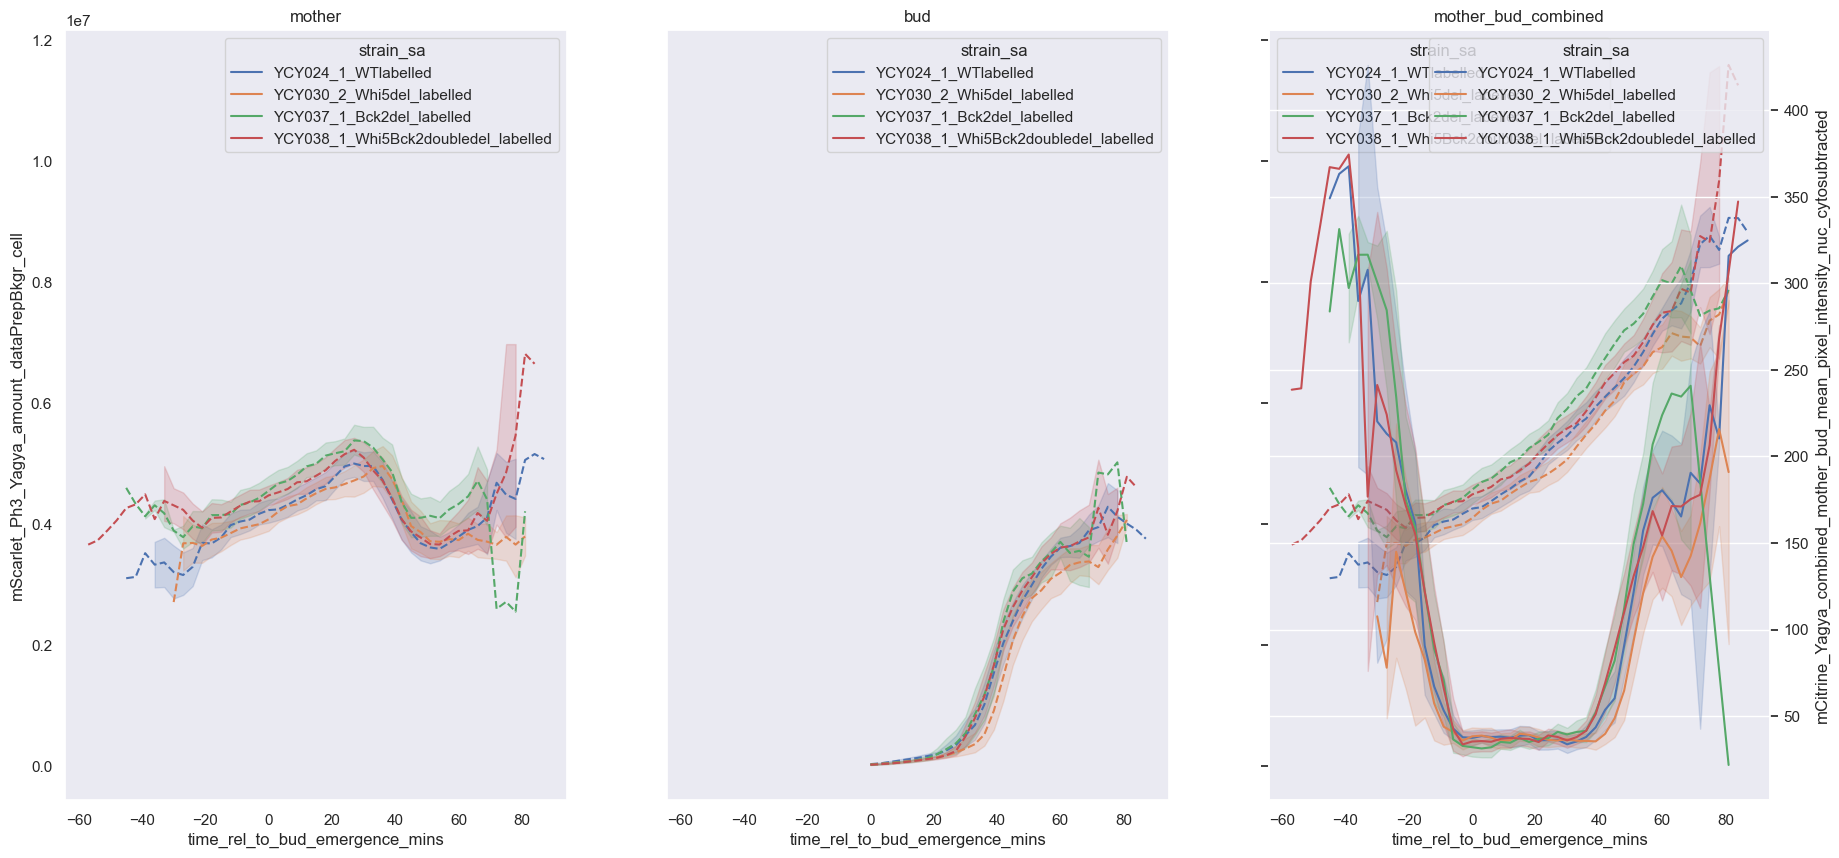

In [81]:
f, ((ax1),(ax2), (ax3)) = plt.subplots(nrows=1, ncols=3, figsize=(22, 10), sharey = True, sharex= True)
f= sns.lineplot(x = "time_rel_to_bud_emergence_mins", 
                y = "mScarlet_Ph3_Yagya_amount_dataPrepBkgr_cell_rel",
                hue = "strain_sa", 
                #kind ="scatter",
                ax = ax2,
                linestyle ='--',
                data =new_complete_preswitch_cycles_df[new_complete_preswitch_cycles_df['strain_sa'] != "MMY"])
f.grid()

f = sns.lineplot(x = "time_rel_to_bud_emergence_mins", 
                y = "mScarlet_Ph3_Yagya_amount_dataPrepBkgr_cell",
                hue = "strain_sa", 
#                style = "custom_G1_stage",
                #kind ="scatter",
                ax = ax1,
                linestyle ='--',
                color = "green",
                data =new_complete_preswitch_cycles_df[new_complete_preswitch_cycles_df['strain_sa'] != "MMY"]
                )
f.grid()
f = sns.lineplot(x = "time_rel_to_bud_emergence_mins", 
                y = "mScarlet_Ph3_Yagya_combined_amount_mother_bud_cell",
                hue = "strain_sa", 
                #kind ="scatter",
                ax = ax3,
                color = "green",
                linestyle ='--',
                data =new_complete_preswitch_cycles_df[new_complete_preswitch_cycles_df['strain_sa'] != "MMY"]
                )
f.grid()
ax3 = plt.twinx()

f= sns.lineplot(x = "time_rel_to_bud_emergence_mins", 
                y = "mCitrine_Yagya_combined_mother_bud_mean_pixel_intensity_nuc_cytosubtracted",
                hue = "strain_sa", 
                #kind ="scatter",
                ax = ax3,
                data =new_complete_preswitch_cycles_df[new_complete_preswitch_cycles_df['strain_sa'] != "MMY"])
ax1.set_title("mother")
ax2.set_title("bud")
ax3.set_title("mother_bud_combined")
#a.set_axis_labels("Time in cell cycle (mins)", "rel_mScarlet_Ph3_Yagya_amount_dataPrepBkgr_cell", size = 15)

plt.show

# ***find cell cycle ids of complete first G1s of first daughters of S/G2/M switchers*** 

In [82]:
ids_first_S_daughters = overall_df[(overall_df['S_switch_cells_daughter_wave_sa'] == 1)
                                                    & ((overall_df['post_switch_gen_sa'] == 1)|
                                                    (overall_df['post_switch_gen_sa'] == "1.0"))
                                                    & (overall_df['complete_phase_sa'] == 1)
                                                    & (overall_df['relationship_sa'] != "bud")
                                                    ].f_pos_cell_id_sa.unique()



# ***find cell cycle ids of mothers of these daughters^*** 

In [83]:
import warnings

switch_mums = []
with warnings.catch_warnings(record=True):
     for rep in overall_df['rep'].unique():
        rep_df = overall_df[(overall_df['rep'] == rep) & (overall_df['strain_sa'] != "MMY")]
        for cellcycle in rep_df['f_pos_cell_id_sa'].unique():
            cycle_df = rep_df[rep_df['f_pos_cell_id_sa'] == cellcycle]
            if cellcycle in ids_first_S_daughters:
                
                cell = cycle_df['Cell_ID'].iloc[0]
                pos = cycle_df['Position_n'].iloc[0]
                strain = cycle_df['strain_sa'].iloc[0] 
                rep = cycle_df['rep'].iloc[0]
                #display(cellcycle)
                
                G1_df = cycle_df[cycle_df['cell_cycle_stage_sa'] == "G1"]
                if len(G1_df) > 0:
                    mother_id = G1_df['relative_ID'].iloc[0]
                    #display(mother_id, rep, strain, pos)
                    mother_switch_df = rep_df[(rep_df['rep'] == rep) &
                                    (rep_df['strain_sa'] == strain) &
                                    (rep_df['Position_n'] == pos) &
                                    (rep_df['Cell_ID'] == mother_id) &
                                    (rep_df['cycle_saw_switch_sa'] == True) 
                                   ]
                    switch_mums.append(mother_switch_df.f_pos_cell_id_sa.iloc[0])

# ***get cell cycle ids of all mothers at switch, regardless of whether they or their daughters have complete cycles*** 

In [84]:
moms_frame50_df = overall_df[(overall_df['cell_cycle_stage_sa'] == "S") &
                                     (overall_df['frame_i'] == 50) &
                                     (overall_df['relationship'] == "mother")]
moms_frame50_ids = moms_frame50_df.f_pos_cell_id_sa.unique().tolist()

# ***for both mothers with complete daughters (switch_mums) and mothers with imcomplete daughters (switch_mums_not_covered_in_complete_daughter_analysis), plot Whi5 signal curve***
# ***using the hover function from mplcursors, manually determine frame of Whi5 re-entry into nucleus for both sets of mothers*** 

In [85]:
#from mplcursors import cursor

In [86]:
switch_mums_not_covered_in_complete_daughter_analysis = list(set(moms_frame50_ids) - set(switch_mums))

In [87]:
# %matplotlib qt 

# current_cohort = switch_mums_not_covered_in_complete_daughter_analysis[126:]
# data = overall_df[overall_df['f_pos_cell_id_sa'].isin(current_cohort)].reset_index(drop = True)
# a = sns.relplot( kind = "scatter",
#             data = data, 
#             x = "frame_i", 
#             y = "mCitrine_Yagya_combined_mother_bud_mean_pixel_intensity_nuc_cytosubtracted", 
#             col  = "f_pos_cell_id_sa",
#             col_order =['YCY037_1_Bck2del_labelled_Position_19_Cell_1_Gen_1_Rep_1',
#  'YCY038_1_Whi5Bck2doubledel_labelled_Position_23_Cell_6_Gen_1_Rep_1',
#  'YCY038_1_Whi5Bck2doubledel_labelled_Position_26_Cell_1_Gen_3_Rep_2',
#  'YCY038_1_Whi5Bck2doubledel_labelled_Position_28_Cell_6_Gen_1_Rep_2',
#  'YCY037_1_Bck2del_labelled_Position_19_Cell_4_Gen_3_Rep_1'],
#             hue = "cell_cycle_stage_sa",
#             col_wrap = 2)
    

# cursor(hover = True)
# plt.show()

# ***record manually determined first frame of whi5 nuclear reentry as list***

In [88]:
### manually determine frame of whi5 re-entry into nuclei of sg2m switchers for incomplete s switchers or ones with incomplete daughters

manually_annotated_whi5_reentry_s_switchers_incomplete_or_incomplete_daughters =  [
['YCY030_2_Whi5del_labelled_Position_13_Cell_6_Gen_4_Rep_1', 45], 
['YCY038_1_Whi5Bck2doubledel_labelled_Position_28_Cell_13_Gen_4_Rep_2',119],
[ 'YCY037_1_Bck2del_labelled_Position_19_Cell_2_Gen_3_Rep_1', 58], 
[ 'YCY024_1_WTlabelled_Position_3_Cell_6_Gen_4_Rep_1', 100],
['YCY030_2_Whi5del_labelled_Position_18_Cell_1_Gen_3_Rep_2', np.nan],
[ 'YCY024_1_WTlabelled_Position_11_Cell_17_Gen_1_Rep_2', np.nan],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_22_Cell_3_Gen_4_Rep_1',142],
[ 'YCY030_2_Whi5del_labelled_Position_14_Cell_10_Gen_1_Rep_1', 142],
[ 'YCY037_1_Bck2del_labelled_Position_20_Cell_12_Gen_1_Rep_2',153],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_28_Cell_10_Gen_2_Rep_2', 145],
[ 'YCY037_1_Bck2del_labelled_Position_20_Cell_8_Gen_1_Rep_1', 178],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_28_Cell_28_Gen_1_Rep_2', 192],
[ 'YCY037_1_Bck2del_labelled_Position_19_Cell_1_Gen_1_Rep_2',43],
[ 'YCY030_2_Whi5del_labelled_Position_17_Cell_8_Gen_1_Rep_2',184],
[ 'YCY037_1_Bck2del_labelled_Position_15_Cell_2_Gen_1_Rep_1',np.nan],
[ 'YCY030_2_Whi5del_labelled_Position_12_Cell_4_Gen_1_Rep_1', 203],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_28_Cell_7_Gen_1_Rep_1', 152],
[ 'YCY037_1_Bck2del_labelled_Position_19_Cell_8_Gen_1_Rep_1',131],
[ 'YCY024_1_WTlabelled_Position_3_Cell_14_Gen_1_Rep_1',140],
[ 'YCY030_2_Whi5del_labelled_Position_13_Cell_7_Gen_2_Rep_1',np.nan],
[ 'YCY037_1_Bck2del_labelled_Position_20_Cell_5_Gen_4_Rep_1',134],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_25_Cell_5_Gen_2_Rep_1',145],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_28_Cell_22_Gen_1_Rep_2',134],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_26_Cell_11_Gen_1_Rep_1',209],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_25_Cell_6_Gen_4_Rep_1',np.nan],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_28_Cell_14_Gen_4_Rep_2', 65],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_29_Cell_4_Gen_1_Rep_2',41],
[ 'YCY024_1_WTlabelled_Position_3_Cell_17_Gen_1_Rep_1',149],
[ 'YCY024_1_WTlabelled_Position_11_Cell_4_Gen_3_Rep_2',59],
[ 'YCY037_1_Bck2del_labelled_Position_21_Cell_6_Gen_1_Rep_1',195],
[ 'YCY030_2_Whi5del_labelled_Position_13_Cell_4_Gen_1_Rep_2',151],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_26_Cell_9_Gen_1_Rep_1',np.nan],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_28_Cell_4_Gen_4_Rep_1',119],
[ 'YCY030_2_Whi5del_labelled_Position_10_Cell_21_Gen_3_Rep_1',np.nan],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_28_Cell_34_Gen_1_Rep_2',159],
[ 'YCY037_1_Bck2del_labelled_Position_19_Cell_17_Gen_1_Rep_1',162],
[ 'YCY030_2_Whi5del_labelled_Position_13_Cell_3_Gen_4_Rep_2',np.nan],
[ 'YCY030_2_Whi5del_labelled_Position_11_Cell_2_Gen_4_Rep_1',73],
[ 'YCY037_1_Bck2del_labelled_Position_16_Cell_9_Gen_1_Rep_1',162],
[ 'YCY030_2_Whi5del_labelled_Position_15_Cell_5_Gen_1_Rep_2',np.nan],
[ 'YCY030_2_Whi5del_labelled_Position_14_Cell_11_Gen_1_Rep_1',192],
[ 'YCY037_1_Bck2del_labelled_Position_19_Cell_9_Gen_1_Rep_2',207],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_28_Cell_2_Gen_3_Rep_1',56],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_25_Cell_3_Gen_4_Rep_1',40],
[ 'YCY037_1_Bck2del_labelled_Position_20_Cell_6_Gen_1_Rep_1',np.nan],
[ 'YCY037_1_Bck2del_labelled_Position_21_Cell_2_Gen_3_Rep_1',41],
[ 'YCY037_1_Bck2del_labelled_Position_20_Cell_4_Gen_3_Rep_1',138],
[ 'YCY024_1_WTlabelled_Position_8_Cell_7_Gen_1_Rep_2',118],
[ 'YCY030_2_Whi5del_labelled_Position_11_Cell_5_Gen_1_Rep_1',np.nan],
[ 'YCY024_1_WTlabelled_Position_12_Cell_2_Gen_3_Rep_2',np.nan],
[ 'YCY030_2_Whi5del_labelled_Position_15_Cell_3_Gen_1_Rep_2',np.nan],
[ 'YCY037_1_Bck2del_labelled_Position_17_Cell_8_Gen_1_Rep_1',np.nan],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_27_Cell_6_Gen_3_Rep_2',59],
[ 'YCY037_1_Bck2del_labelled_Position_18_Cell_6_Gen_1_Rep_1',np.nan],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_30_Cell_4_Gen_1_Rep_2',np.nan],
[ 'YCY024_1_WTlabelled_Position_3_Cell_7_Gen_2_Rep_1',70],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_27_Cell_53_Gen_1_Rep_2',157],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_28_Cell_3_Gen_4_Rep_1',45],
[ 'YCY037_1_Bck2del_labelled_Position_21_Cell_1_Gen_3_Rep_1',211],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_29_Cell_10_Gen_1_Rep_2',264],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_29_Cell_8_Gen_1_Rep_2',308],
[ 'YCY037_1_Bck2del_labelled_Position_16_Cell_6_Gen_4_Rep_1',np.nan],
[ 'YCY037_1_Bck2del_labelled_Position_21_Cell_1_Gen_1_Rep_2',47],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_26_Cell_4_Gen_4_Rep_1',49],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_22_Cell_2_Gen_2_Rep_1',218],
[ 'YCY037_1_Bck2del_labelled_Position_20_Cell_1_Gen_1_Rep_1',236],
[ 'YCY037_1_Bck2del_labelled_Position_17_Cell_2_Gen_3_Rep_1',54],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_25_Cell_17_Gen_1_Rep_1',178],
[ 'YCY037_1_Bck2del_labelled_Position_19_Cell_16_Gen_1_Rep_1',200],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_27_Cell_25_Gen_1_Rep_2',52],
[ 'YCY030_2_Whi5del_labelled_Position_11_Cell_3_Gen_4_Rep_1',158],
[ 'YCY037_1_Bck2del_labelled_Position_21_Cell_13_Gen_1_Rep_1',46],
[ 'YCY037_1_Bck2del_labelled_Position_17_Cell_3_Gen_1_Rep_1',182],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_28_Cell_15_Gen_2_Rep_2',149],
[ 'YCY037_1_Bck2del_labelled_Position_22_Cell_3_Gen_1_Rep_2',112],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_25_Cell_1_Gen_1_Rep_2',50],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_23_Cell_10_Gen_1_Rep_1',196],
[ 'YCY030_2_Whi5del_labelled_Position_10_Cell_26_Gen_1_Rep_1',245],
[ 'YCY024_1_WTlabelled_Position_3_Cell_4_Gen_3_Rep_1',81],
[ 'YCY024_1_WTlabelled_Position_8_Cell_6_Gen_3_Rep_2',77],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_28_Cell_12_Gen_3_Rep_2',86],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_28_Cell_7_Gen_4_Rep_2',140],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_27_Cell_8_Gen_3_Rep_2',43],
[ 'YCY030_2_Whi5del_labelled_Position_14_Cell_6_Gen_2_Rep_1',196],
[ 'YCY024_1_WTlabelled_Position_12_Cell_4_Gen_1_Rep_2',np.nan],
[ 'YCY037_1_Bck2del_labelled_Position_17_Cell_1_Gen_4_Rep_1',319],
[ 'YCY037_1_Bck2del_labelled_Position_19_Cell_2_Gen_3_Rep_2',48],
[ 'YCY030_2_Whi5del_labelled_Position_9_Cell_2_Gen_4_Rep_1',197],
[ 'YCY037_1_Bck2del_labelled_Position_16_Cell_3_Gen_3_Rep_1',265],
[ 'YCY037_1_Bck2del_labelled_Position_21_Cell_2_Gen_3_Rep_2',115],
[ 'YCY037_1_Bck2del_labelled_Position_24_Cell_3_Gen_1_Rep_2',np.nan],
[ 'YCY030_2_Whi5del_labelled_Position_15_Cell_2_Gen_3_Rep_2',np.nan],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_23_Cell_1_Gen_3_Rep_1',141],
[ 'YCY030_2_Whi5del_labelled_Position_12_Cell_1_Gen_4_Rep_1',207],
[ 'YCY024_1_WTlabelled_Position_5_Cell_23_Gen_1_Rep_1',186],
[ 'YCY037_1_Bck2del_labelled_Position_19_Cell_5_Gen_3_Rep_2',53],
[ 'YCY037_1_Bck2del_labelled_Position_23_Cell_1_Gen_3_Rep_2',44],
[ 'YCY037_1_Bck2del_labelled_Position_16_Cell_2_Gen_4_Rep_1',np.nan],
[ 'YCY030_2_Whi5del_labelled_Position_12_Cell_5_Gen_1_Rep_1',302],
[ 'YCY024_1_WTlabelled_Position_11_Cell_3_Gen_4_Rep_2',131],
[ 'YCY030_2_Whi5del_labelled_Position_14_Cell_3_Gen_4_Rep_1',139],
[ 'YCY037_1_Bck2del_labelled_Position_17_Cell_6_Gen_3_Rep_1',166],
[ 'YCY037_1_Bck2del_labelled_Position_19_Cell_12_Gen_3_Rep_1',42],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_28_Cell_8_Gen_1_Rep_1',43],
[ 'YCY037_1_Bck2del_labelled_Position_19_Cell_7_Gen_1_Rep_1',np.nan],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_28_Cell_11_Gen_3_Rep_2',104],
[ 'YCY037_1_Bck2del_labelled_Position_20_Cell_1_Gen_3_Rep_2',50],
[ 'YCY024_1_WTlabelled_Position_5_Cell_18_Gen_1_Rep_1',54],
[ 'YCY037_1_Bck2del_labelled_Position_16_Cell_8_Gen_1_Rep_1',41],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_28_Cell_5_Gen_2_Rep_1',220],
[ 'YCY037_1_Bck2del_labelled_Position_16_Cell_4_Gen_3_Rep_1',46],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_26_Cell_1_Gen_1_Rep_1',54],
[ 'YCY024_1_WTlabelled_Position_9_Cell_5_Gen_1_Rep_2',np.nan],
[ 'YCY024_1_WTlabelled_Position_3_Cell_15_Gen_1_Rep_1',86],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_24_Cell_2_Gen_4_Rep_1',121],
[ 'YCY037_1_Bck2del_labelled_Position_18_Cell_1_Gen_3_Rep_1',148],
[ 'YCY024_1_WTlabelled_Position_12_Cell_5_Gen_1_Rep_2',173],
[ 'YCY024_1_WTlabelled_Position_8_Cell_11_Gen_1_Rep_2',np.nan],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_27_Cell_7_Gen_4_Rep_2',118],
[ 'YCY030_2_Whi5del_labelled_Position_11_Cell_7_Gen_1_Rep_1',202],
[ 'YCY030_2_Whi5del_labelled_Position_14_Cell_5_Gen_2_Rep_1',177],
[ 'YCY024_1_WTlabelled_Position_5_Cell_5_Gen_4_Rep_1',100],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_23_Cell_3_Gen_4_Rep_1',202],
[ 'YCY037_1_Bck2del_labelled_Position_16_Cell_7_Gen_4_Rep_1',np.nan],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_27_Cell_3_Gen_1_Rep_1',89],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_27_Cell_9_Gen_2_Rep_2',127],
[ 'YCY037_1_Bck2del_labelled_Position_19_Cell_1_Gen_1_Rep_1',40],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_23_Cell_6_Gen_1_Rep_1',171],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_26_Cell_1_Gen_3_Rep_2',454],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_28_Cell_6_Gen_1_Rep_2',np.nan],
[ 'YCY037_1_Bck2del_labelled_Position_19_Cell_4_Gen_3_Rep_1',43]
]


### manually determine frame of whi5 re-entry into nuclei of sg2m switchers with complete daughters

manually_annotated_whi5_reentry_s_switchers_complete_daughters =  [['YCY024_1_WTlabelled_Position_1_Cell_2_Gen_4_Rep_1', 142],                                                                                                    
['YCY024_1_WTlabelled_Position_1_Cell_3_Gen_1_Rep_1',152],
['YCY024_1_WTlabelled_Position_2_Cell_2_Gen_3_Rep_1',54],
['YCY024_1_WTlabelled_Position_2_Cell_4_Gen_1_Rep_1',106],
['YCY024_1_WTlabelled_Position_2_Cell_5_Gen_1_Rep_1',151],
['YCY024_1_WTlabelled_Position_2_Cell_1_Gen_4_Rep_1',np.nan],
['YCY024_1_WTlabelled_Position_3_Cell_5_Gen_1_Rep_1',44],
['YCY024_1_WTlabelled_Position_3_Cell_11_Gen_1_Rep_1',56],
['YCY024_1_WTlabelled_Position_4_Cell_3_Gen_4_Rep_1',67],
['YCY024_1_WTlabelled_Position_4_Cell_7_Gen_1_Rep_1',99],
['YCY024_1_WTlabelled_Position_4_Cell_4_Gen_4_Rep_1',113],
['YCY024_1_WTlabelled_Position_4_Cell_1_Gen_2_Rep_1',137],
['YCY024_1_WTlabelled_Position_5_Cell_2_Gen_1_Rep_1',43],
['YCY024_1_WTlabelled_Position_5_Cell_1_Gen_3_Rep_1',43],
[ 'YCY024_1_WTlabelled_Position_5_Cell_6_Gen_3_Rep_1',45],
['YCY024_1_WTlabelled_Position_5_Cell_17_Gen_1_Rep_1',84],
['YCY024_1_WTlabelled_Position_7_Cell_1_Gen_1_Rep_1',49],
['YCY024_1_WTlabelled_Position_7_Cell_2_Gen_3_Rep_1',64],
['YCY024_1_WTlabelled_Position_7_Cell_4_Gen_1_Rep_1',61],
['YCY030_2_Whi5del_labelled_Position_8_Cell_2_Gen_3_Rep_1',41],
['YCY030_2_Whi5del_labelled_Position_8_Cell_3_Gen_1_Rep_1',np.nan],
['YCY030_2_Whi5del_labelled_Position_8_Cell_1_Gen_3_Rep_1',87],
['YCY030_2_Whi5del_labelled_Position_8_Cell_4_Gen_1_Rep_1',195],
['YCY030_2_Whi5del_labelled_Position_9_Cell_3_Gen_1_Rep_1',44],
['YCY030_2_Whi5del_labelled_Position_10_Cell_20_Gen_1_Rep_1',43],
['YCY030_2_Whi5del_labelled_Position_11_Cell_1_Gen_2_Rep_1',np.nan],
['YCY030_2_Whi5del_labelled_Position_11_Cell_9_Gen_1_Rep_1',192],
['YCY030_2_Whi5del_labelled_Position_12_Cell_2_Gen_2_Rep_1',148],
['YCY030_2_Whi5del_labelled_Position_13_Cell_5_Gen_3_Rep_1',40],
['YCY030_2_Whi5del_labelled_Position_13_Cell_24_Gen_1_Rep_1',238],
['YCY030_2_Whi5del_labelled_Position_14_Cell_4_Gen_4_Rep_1',44],
['YCY030_2_Whi5del_labelled_Position_14_Cell_9_Gen_1_Rep_1',71],
['YCY037_1_Bck2del_labelled_Position_17_Cell_11_Gen_1_Rep_1',121],
['YCY037_1_Bck2del_labelled_Position_17_Cell_7_Gen_3_Rep_1',197],
['YCY037_1_Bck2del_labelled_Position_19_Cell_9_Gen_3_Rep_1', np.nan],
['YCY037_1_Bck2del_labelled_Position_19_Cell_19_Gen_1_Rep_1',219],
['YCY037_1_Bck2del_labelled_Position_21_Cell_9_Gen_1_Rep_1',148],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_22_Cell_5_Gen_1_Rep_1',51],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_23_Cell_8_Gen_1_Rep_1',45],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_24_Cell_3_Gen_1_Rep_1',43],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_24_Cell_8_Gen_1_Rep_1',291],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_25_Cell_11_Gen_1_Rep_1',50],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_25_Cell_4_Gen_4_Rep_1',153],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_25_Cell_1_Gen_2_Rep_1',180],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_26_Cell_6_Gen_2_Rep_1',139],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_26_Cell_3_Gen_2_Rep_1', 141],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_26_Cell_8_Gen_1_Rep_1', 148],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_27_Cell_2_Gen_3_Rep_1',44],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_28_Cell_1_Gen_1_Rep_1',43],
['YCY024_1_WTlabelled_Position_7_Cell_4_Gen_1_Rep_2',120],
['YCY024_1_WTlabelled_Position_7_Cell_7_Gen_1_Rep_2',193],
['YCY024_1_WTlabelled_Position_7_Cell_2_Gen_4_Rep_2',159],
['YCY024_1_WTlabelled_Position_7_Cell_1_Gen_2_Rep_2',164],
['YCY024_1_WTlabelled_Position_8_Cell_2_Gen_1_Rep_2',50],
['YCY024_1_WTlabelled_Position_8_Cell_4_Gen_4_Rep_2', 157],
['YCY024_1_WTlabelled_Position_8_Cell_1_Gen_2_Rep_2', 157],
['YCY024_1_WTlabelled_Position_8_Cell_3_Gen_4_Rep_2',180],
['YCY024_1_WTlabelled_Position_9_Cell_2_Gen_1_Rep_2',44],
['YCY024_1_WTlabelled_Position_9_Cell_1_Gen_3_Rep_2',167],
['YCY024_1_WTlabelled_Position_9_Cell_4_Gen_4_Rep_2',172],
['YCY024_1_WTlabelled_Position_10_Cell_3_Gen_3_Rep_2',157],
['YCY024_1_WTlabelled_Position_10_Cell_1_Gen_1_Rep_2',193],
['YCY024_1_WTlabelled_Position_10_Cell_5_Gen_1_Rep_2',247],
['YCY024_1_WTlabelled_Position_11_Cell_2_Gen_3_Rep_2',40],
['YCY024_1_WTlabelled_Position_11_Cell_6_Gen_1_Rep_2',62],
['YCY024_1_WTlabelled_Position_11_Cell_10_Gen_1_Rep_2',172],
['YCY024_1_WTlabelled_Position_11_Cell_5_Gen_3_Rep_2',164],
['YCY024_1_WTlabelled_Position_12_Cell_3_Gen_4_Rep_2',349],
['YCY024_1_WTlabelled_Position_12_Cell_1_Gen_2_Rep_2',272],
['YCY030_2_Whi5del_labelled_Position_13_Cell_6_Gen_1_Rep_2',209],
['YCY030_2_Whi5del_labelled_Position_13_Cell_2_Gen_4_Rep_2',220],
['YCY030_2_Whi5del_labelled_Position_14_Cell_2_Gen_3_Rep_2',200],
['YCY030_2_Whi5del_labelled_Position_14_Cell_7_Gen_1_Rep_2',194],
['YCY030_2_Whi5del_labelled_Position_14_Cell_4_Gen_3_Rep_2',223],
['YCY030_2_Whi5del_labelled_Position_14_Cell_3_Gen_4_Rep_2',213],
['YCY030_2_Whi5del_labelled_Position_16_Cell_2_Gen_3_Rep_2',42],
['YCY030_2_Whi5del_labelled_Position_16_Cell_5_Gen_1_Rep_2',55],
['YCY030_2_Whi5del_labelled_Position_16_Cell_3_Gen_4_Rep_2',161],
['YCY030_2_Whi5del_labelled_Position_16_Cell_11_Gen_1_Rep_2',192],
['YCY030_2_Whi5del_labelled_Position_17_Cell_2_Gen_2_Rep_2',202],
['YCY030_2_Whi5del_labelled_Position_17_Cell_3_Gen_4_Rep_2',188],
['YCY030_2_Whi5del_labelled_Position_17_Cell_11_Gen_1_Rep_2',243],
['YCY030_2_Whi5del_labelled_Position_17_Cell_9_Gen_1_Rep_2',206],
['YCY030_2_Whi5del_labelled_Position_17_Cell_1_Gen_2_Rep_2',225],
['YCY030_2_Whi5del_labelled_Position_18_Cell_2_Gen_3_Rep_2',43],
['YCY030_2_Whi5del_labelled_Position_18_Cell_4_Gen_1_Rep_2',85],
['YCY037_1_Bck2del_labelled_Position_19_Cell_6_Gen_1_Rep_2',161],
['YCY037_1_Bck2del_labelled_Position_19_Cell_8_Gen_1_Rep_2',172],
['YCY037_1_Bck2del_labelled_Position_19_Cell_4_Gen_4_Rep_2', 138],
['YCY037_1_Bck2del_labelled_Position_21_Cell_3_Gen_4_Rep_2',241],
['YCY037_1_Bck2del_labelled_Position_23_Cell_2_Gen_1_Rep_2',187],
['YCY037_1_Bck2del_labelled_Position_23_Cell_3_Gen_4_Rep_2',207],
['YCY037_1_Bck2del_labelled_Position_24_Cell_2_Gen_3_Rep_2',52],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_26_Cell_14_Gen_1_Rep_2',126],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_26_Cell_2_Gen_3_Rep_2',174],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_26_Cell_15_Gen_1_Rep_2',136],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_27_Cell_31_Gen_1_Rep_2',172],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_27_Cell_56_Gen_1_Rep_2',177],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_28_Cell_17_Gen_4_Rep_2',122],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_28_Cell_9_Gen_4_Rep_2',140],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_28_Cell_19_Gen_1_Rep_2',137],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_29_Cell_3_Gen_3_Rep_2',135],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_29_Cell_5_Gen_4_Rep_2',209],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_30_Cell_3_Gen_1_Rep_2',44],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_30_Cell_9_Gen_4_Rep_2',104],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_30_Cell_21_Gen_1_Rep_2',137],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_30_Cell_10_Gen_2_Rep_2',147]]

# ***make df from this list and add this info to overall_df***

In [89]:
# make df from above lists

manually_annotated_whi5_reentry_s_switchers_df = pd.DataFrame(manually_annotated_whi5_reentry_s_switchers_complete_daughters, 
                                                              columns = ['f_pos_cell_id_sa', 'first_postmitotic_frame_manual'] )

manually_annotated_whi5_reentry_s_switchers_incomplete_or_incomplete_daughters_df = pd.DataFrame(manually_annotated_whi5_reentry_s_switchers_incomplete_or_incomplete_daughters, 
                                                              columns = ['f_pos_cell_id_sa', 'first_postmitotic_frame_manual'] )

In [90]:
### add this whi5-reentry-frame info to overall_df

for cycle in manually_annotated_whi5_reentry_s_switchers_df.f_pos_cell_id_sa.unique():
    whi5_reentry_frame = manually_annotated_whi5_reentry_s_switchers_df.loc[(manually_annotated_whi5_reentry_s_switchers_df['f_pos_cell_id_sa'] == cycle), 'first_postmitotic_frame_manual']
    
    overall_df.loc[(overall_df['f_pos_cell_id_sa'] == cycle), 'first_postmitotic_frame_manual'] = whi5_reentry_frame.iloc[0]
    


### merge df 

for cycle in manually_annotated_whi5_reentry_s_switchers_incomplete_or_incomplete_daughters_df.f_pos_cell_id_sa.unique():
    whi5_reentry_frame = manually_annotated_whi5_reentry_s_switchers_incomplete_or_incomplete_daughters_df.loc[(manually_annotated_whi5_reentry_s_switchers_incomplete_or_incomplete_daughters_df['f_pos_cell_id_sa'] == cycle), 'first_postmitotic_frame_manual']
    
    overall_df.loc[(overall_df['f_pos_cell_id_sa'] == cycle), 'first_postmitotic_frame_manual'] = whi5_reentry_frame.iloc[0]
    

    

# ***based on whi5 reentry frame, split and label S-phase into postMitotic and notPostMitotic***

In [91]:

overall_df['custom_S_postmitoticstage_manual'] = np.nan



list_for_appending = []
with warnings.catch_warnings(record=True):
    for cellcycle in overall_df['f_pos_cell_id_sa'].unique():
        cycle_df = overall_df[overall_df['f_pos_cell_id_sa'] == cellcycle]
        if cellcycle in moms_frame50_ids:
            first_postmitotic_frame_manual = cycle_df['first_postmitotic_frame_manual'].iloc[0]
            if np.isnan(first_postmitotic_frame_manual) == False:
                cycle_df.loc[(cycle_df['cell_cycle_stage_sa'] == "S") & (cycle_df['frame_i'] >= first_postmitotic_frame_manual), 'custom_S_postmitoticstage_manual'] = "postMitotic"
                cycle_df.loc[(cycle_df['cell_cycle_stage_sa'] == "S") & (cycle_df['frame_i'] < first_postmitotic_frame_manual), 'custom_S_postmitoticstage_manual'] = "notPostMitotic"
            
        list_for_appending.append(cycle_df)
            
overall_df = pd.concat(list_for_appending).reset_index(drop = True)                        

                    

# ***for both mothers with complete daughters (switch_mums) and mothers with imcomplete daughters (switch_mums_not_covered_in_complete_daughter_analysis), plot HTB2 signal in the bud***
# ***using the hover function from mplcursors, manually determine frame of HTB2 entry into bud for both sets of mothers*** 

In [92]:
# %matplotlib qt 

# current_cohort = switch_mums_not_covered_in_complete_daughter_analysis[126:]
# data = overall_df[overall_df['f_pos_cell_id_sa'].isin(current_cohort)].reset_index(drop = True)
# a = sns.relplot( kind = "scatter",
#             data = data, 
#             x = "frame_i", 
#             y = "mScarlet_Ph3_Yagya_amount_dataPrepBkgr_cell_rel", 
#             col  = "f_pos_cell_id_sa",
#             col_order =['YCY037_1_Bck2del_labelled_Position_19_Cell_1_Gen_1_Rep_1',
#  'YCY038_1_Whi5Bck2doubledel_labelled_Position_23_Cell_6_Gen_1_Rep_1',
#  'YCY038_1_Whi5Bck2doubledel_labelled_Position_26_Cell_1_Gen_3_Rep_2',
#  'YCY038_1_Whi5Bck2doubledel_labelled_Position_28_Cell_6_Gen_1_Rep_2',
#  'YCY037_1_Bck2del_labelled_Position_19_Cell_4_Gen_3_Rep_1'],
#             hue = "cell_cycle_stage_sa",
#             col_wrap = 2)
    

# cursor(hover = True)
# plt.show()

# ***record manually determined first frame of HTB2 bud entry as list***

In [93]:
### manually histone entry into buds for incomplete s switchers or ones with incomplete daughters

manually_annotated_hist_entry_buds_of_s_switchers_incomplete_or_incomplete_daughters =  [
['YCY030_2_Whi5del_labelled_Position_13_Cell_6_Gen_4_Rep_1', 41], 
['YCY038_1_Whi5Bck2doubledel_labelled_Position_28_Cell_13_Gen_4_Rep_2',108],
[ 'YCY037_1_Bck2del_labelled_Position_19_Cell_2_Gen_3_Rep_1', 41], 
[ 'YCY024_1_WTlabelled_Position_3_Cell_6_Gen_4_Rep_1',94 ],
['YCY030_2_Whi5del_labelled_Position_18_Cell_1_Gen_3_Rep_2', np.nan],
[ 'YCY024_1_WTlabelled_Position_11_Cell_17_Gen_1_Rep_2', 161],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_22_Cell_3_Gen_4_Rep_1',132],
[ 'YCY030_2_Whi5del_labelled_Position_14_Cell_10_Gen_1_Rep_1', 130],
[ 'YCY037_1_Bck2del_labelled_Position_20_Cell_12_Gen_1_Rep_2',127],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_28_Cell_10_Gen_2_Rep_2', 136],
[ 'YCY037_1_Bck2del_labelled_Position_20_Cell_8_Gen_1_Rep_1', 171],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_28_Cell_28_Gen_1_Rep_2', 183],    
[ 'YCY037_1_Bck2del_labelled_Position_19_Cell_1_Gen_1_Rep_2',40],
[ 'YCY030_2_Whi5del_labelled_Position_17_Cell_8_Gen_1_Rep_2',181],
[ 'YCY037_1_Bck2del_labelled_Position_15_Cell_2_Gen_1_Rep_1',153],
[ 'YCY030_2_Whi5del_labelled_Position_12_Cell_4_Gen_1_Rep_1',np.nan],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_28_Cell_7_Gen_1_Rep_1', 143],
[ 'YCY037_1_Bck2del_labelled_Position_19_Cell_8_Gen_1_Rep_1',np.nan],    
[ 'YCY024_1_WTlabelled_Position_3_Cell_14_Gen_1_Rep_1',135],
[ 'YCY030_2_Whi5del_labelled_Position_13_Cell_7_Gen_2_Rep_1',223],
[ 'YCY037_1_Bck2del_labelled_Position_20_Cell_5_Gen_4_Rep_1',62],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_25_Cell_5_Gen_2_Rep_1',140],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_28_Cell_22_Gen_1_Rep_2',128],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_26_Cell_11_Gen_1_Rep_1',202],    
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_25_Cell_6_Gen_4_Rep_1',np.nan],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_28_Cell_14_Gen_4_Rep_2', 46],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_29_Cell_4_Gen_1_Rep_2',38],
[ 'YCY024_1_WTlabelled_Position_3_Cell_17_Gen_1_Rep_1',145],
[ 'YCY024_1_WTlabelled_Position_11_Cell_4_Gen_3_Rep_2',44],
[ 'YCY037_1_Bck2del_labelled_Position_21_Cell_6_Gen_1_Rep_1',192],    
[ 'YCY030_2_Whi5del_labelled_Position_13_Cell_4_Gen_1_Rep_2',141],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_26_Cell_9_Gen_1_Rep_1',275],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_28_Cell_4_Gen_4_Rep_1',115],
[ 'YCY030_2_Whi5del_labelled_Position_10_Cell_21_Gen_3_Rep_1',144],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_28_Cell_34_Gen_1_Rep_2',149],
[ 'YCY037_1_Bck2del_labelled_Position_19_Cell_17_Gen_1_Rep_1',157],    
[ 'YCY030_2_Whi5del_labelled_Position_13_Cell_3_Gen_4_Rep_2',np.nan],
[ 'YCY030_2_Whi5del_labelled_Position_11_Cell_2_Gen_4_Rep_1',42],
[ 'YCY037_1_Bck2del_labelled_Position_16_Cell_9_Gen_1_Rep_1',152],
[ 'YCY030_2_Whi5del_labelled_Position_15_Cell_5_Gen_1_Rep_2',np.nan],
[ 'YCY030_2_Whi5del_labelled_Position_14_Cell_11_Gen_1_Rep_1',186],
[ 'YCY037_1_Bck2del_labelled_Position_19_Cell_9_Gen_1_Rep_2',203],    
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_28_Cell_2_Gen_3_Rep_1',43],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_25_Cell_3_Gen_4_Rep_1',37],
[ 'YCY037_1_Bck2del_labelled_Position_20_Cell_6_Gen_1_Rep_1',np.nan],
[ 'YCY037_1_Bck2del_labelled_Position_21_Cell_2_Gen_3_Rep_1',39],
[ 'YCY037_1_Bck2del_labelled_Position_20_Cell_4_Gen_3_Rep_1',131],
[ 'YCY024_1_WTlabelled_Position_8_Cell_7_Gen_1_Rep_2',109],    
[ 'YCY030_2_Whi5del_labelled_Position_11_Cell_5_Gen_1_Rep_1',np.nan],
[ 'YCY024_1_WTlabelled_Position_12_Cell_2_Gen_3_Rep_2',43],
[ 'YCY030_2_Whi5del_labelled_Position_15_Cell_3_Gen_1_Rep_2',np.nan],
[ 'YCY037_1_Bck2del_labelled_Position_17_Cell_8_Gen_1_Rep_1',195],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_27_Cell_6_Gen_3_Rep_2',41],
[ 'YCY037_1_Bck2del_labelled_Position_18_Cell_6_Gen_1_Rep_1',np.nan],    
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_30_Cell_4_Gen_1_Rep_2',109],
[ 'YCY024_1_WTlabelled_Position_3_Cell_7_Gen_2_Rep_1',64],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_27_Cell_53_Gen_1_Rep_2',152],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_28_Cell_3_Gen_4_Rep_1',40],
[ 'YCY037_1_Bck2del_labelled_Position_21_Cell_1_Gen_3_Rep_1',204],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_29_Cell_10_Gen_1_Rep_2',245],    
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_29_Cell_8_Gen_1_Rep_2',300],
[ 'YCY037_1_Bck2del_labelled_Position_16_Cell_6_Gen_4_Rep_1',np.nan],
[ 'YCY037_1_Bck2del_labelled_Position_21_Cell_1_Gen_1_Rep_2',42],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_26_Cell_4_Gen_4_Rep_1',40],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_22_Cell_2_Gen_2_Rep_1',210],
[ 'YCY037_1_Bck2del_labelled_Position_20_Cell_1_Gen_1_Rep_1',229],   
[ 'YCY037_1_Bck2del_labelled_Position_17_Cell_2_Gen_3_Rep_1',44],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_25_Cell_17_Gen_1_Rep_1',168],
[ 'YCY037_1_Bck2del_labelled_Position_19_Cell_16_Gen_1_Rep_1',193],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_27_Cell_25_Gen_1_Rep_2',45],
[ 'YCY030_2_Whi5del_labelled_Position_11_Cell_3_Gen_4_Rep_1',147],
[ 'YCY037_1_Bck2del_labelled_Position_21_Cell_13_Gen_1_Rep_1',np.nan],    
[ 'YCY037_1_Bck2del_labelled_Position_17_Cell_3_Gen_1_Rep_1',177],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_28_Cell_15_Gen_2_Rep_2',143],
[ 'YCY037_1_Bck2del_labelled_Position_22_Cell_3_Gen_1_Rep_2',45],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_25_Cell_1_Gen_1_Rep_2',44],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_23_Cell_10_Gen_1_Rep_1',190],
[ 'YCY030_2_Whi5del_labelled_Position_10_Cell_26_Gen_1_Rep_1',222],    
[ 'YCY024_1_WTlabelled_Position_3_Cell_4_Gen_3_Rep_1',74],
[ 'YCY024_1_WTlabelled_Position_8_Cell_6_Gen_3_Rep_2',69],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_28_Cell_12_Gen_3_Rep_2',62],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_28_Cell_7_Gen_4_Rep_2',134],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_27_Cell_8_Gen_3_Rep_2',39],
[ 'YCY030_2_Whi5del_labelled_Position_14_Cell_6_Gen_2_Rep_1',190],    
[ 'YCY024_1_WTlabelled_Position_12_Cell_4_Gen_1_Rep_2',np.nan],
[ 'YCY037_1_Bck2del_labelled_Position_17_Cell_1_Gen_4_Rep_1',314],
[ 'YCY037_1_Bck2del_labelled_Position_19_Cell_2_Gen_3_Rep_2',41],
[ 'YCY030_2_Whi5del_labelled_Position_9_Cell_2_Gen_4_Rep_1',190],
[ 'YCY037_1_Bck2del_labelled_Position_16_Cell_3_Gen_3_Rep_1',260],
[ 'YCY037_1_Bck2del_labelled_Position_21_Cell_2_Gen_3_Rep_2',53],    
[ 'YCY037_1_Bck2del_labelled_Position_24_Cell_3_Gen_1_Rep_2',np.nan],
[ 'YCY030_2_Whi5del_labelled_Position_15_Cell_2_Gen_3_Rep_2',np.nan],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_23_Cell_1_Gen_3_Rep_1',121],
[ 'YCY030_2_Whi5del_labelled_Position_12_Cell_1_Gen_4_Rep_1',201],
[ 'YCY024_1_WTlabelled_Position_5_Cell_23_Gen_1_Rep_1',179],
[ 'YCY037_1_Bck2del_labelled_Position_19_Cell_5_Gen_3_Rep_2',45],    
[ 'YCY037_1_Bck2del_labelled_Position_23_Cell_1_Gen_3_Rep_2',40],
[ 'YCY037_1_Bck2del_labelled_Position_16_Cell_2_Gen_4_Rep_1',224],
[ 'YCY030_2_Whi5del_labelled_Position_12_Cell_5_Gen_1_Rep_1',296],
[ 'YCY024_1_WTlabelled_Position_11_Cell_3_Gen_4_Rep_2',124],
[ 'YCY030_2_Whi5del_labelled_Position_14_Cell_3_Gen_4_Rep_1',126],
[ 'YCY037_1_Bck2del_labelled_Position_17_Cell_6_Gen_3_Rep_1',43],    
[ 'YCY037_1_Bck2del_labelled_Position_19_Cell_12_Gen_3_Rep_1',40],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_28_Cell_8_Gen_1_Rep_1',38],
[ 'YCY037_1_Bck2del_labelled_Position_19_Cell_7_Gen_1_Rep_1',39],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_28_Cell_11_Gen_3_Rep_2',97],
[ 'YCY037_1_Bck2del_labelled_Position_20_Cell_1_Gen_3_Rep_2',42],
[ 'YCY024_1_WTlabelled_Position_5_Cell_18_Gen_1_Rep_1',45],    
[ 'YCY037_1_Bck2del_labelled_Position_16_Cell_8_Gen_1_Rep_1',37],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_28_Cell_5_Gen_2_Rep_1',191],
[ 'YCY037_1_Bck2del_labelled_Position_16_Cell_4_Gen_3_Rep_1',43],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_26_Cell_1_Gen_1_Rep_1',45],
[ 'YCY024_1_WTlabelled_Position_9_Cell_5_Gen_1_Rep_2',87],
[ 'YCY024_1_WTlabelled_Position_3_Cell_15_Gen_1_Rep_1',81],    
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_24_Cell_2_Gen_4_Rep_1',112],
[ 'YCY037_1_Bck2del_labelled_Position_18_Cell_1_Gen_3_Rep_1',138],
[ 'YCY024_1_WTlabelled_Position_12_Cell_5_Gen_1_Rep_2',167],
[ 'YCY024_1_WTlabelled_Position_8_Cell_11_Gen_1_Rep_2',121],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_27_Cell_7_Gen_4_Rep_2',111],
[ 'YCY030_2_Whi5del_labelled_Position_11_Cell_7_Gen_1_Rep_1',196],    
[ 'YCY030_2_Whi5del_labelled_Position_14_Cell_5_Gen_2_Rep_1',170],
[ 'YCY024_1_WTlabelled_Position_5_Cell_5_Gen_4_Rep_1',94],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_23_Cell_3_Gen_4_Rep_1',194],
[ 'YCY037_1_Bck2del_labelled_Position_16_Cell_7_Gen_4_Rep_1',162],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_27_Cell_3_Gen_1_Rep_1',43],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_27_Cell_9_Gen_2_Rep_2',122],    
[ 'YCY037_1_Bck2del_labelled_Position_19_Cell_1_Gen_1_Rep_1',38],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_23_Cell_6_Gen_1_Rep_1',167],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_26_Cell_1_Gen_3_Rep_2',46],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_28_Cell_6_Gen_1_Rep_2',88],
[ 'YCY037_1_Bck2del_labelled_Position_19_Cell_4_Gen_3_Rep_1',np.nan]
]

### manually assigning histone entry into buds of sg2m switchers

manually_annotated_hist_entry_buds_of_s_switchers =  [['YCY024_1_WTlabelled_Position_1_Cell_2_Gen_4_Rep_1',136 ],                                                                                                    
['YCY024_1_WTlabelled_Position_1_Cell_3_Gen_1_Rep_1',145],
['YCY024_1_WTlabelled_Position_2_Cell_2_Gen_3_Rep_1',44],
['YCY024_1_WTlabelled_Position_2_Cell_4_Gen_1_Rep_1',101],
['YCY024_1_WTlabelled_Position_2_Cell_5_Gen_1_Rep_1',145],
['YCY024_1_WTlabelled_Position_2_Cell_1_Gen_4_Rep_1',np.nan],
['YCY024_1_WTlabelled_Position_3_Cell_5_Gen_1_Rep_1',27],
['YCY024_1_WTlabelled_Position_3_Cell_11_Gen_1_Rep_1',45],
['YCY024_1_WTlabelled_Position_4_Cell_3_Gen_4_Rep_1',46],
['YCY024_1_WTlabelled_Position_4_Cell_7_Gen_1_Rep_1',92],
['YCY024_1_WTlabelled_Position_4_Cell_4_Gen_4_Rep_1',109],
['YCY024_1_WTlabelled_Position_4_Cell_1_Gen_2_Rep_1',131],
['YCY024_1_WTlabelled_Position_5_Cell_2_Gen_1_Rep_1',39],
['YCY024_1_WTlabelled_Position_5_Cell_1_Gen_3_Rep_1',39],
[ 'YCY024_1_WTlabelled_Position_5_Cell_6_Gen_3_Rep_1',42],
['YCY024_1_WTlabelled_Position_5_Cell_17_Gen_1_Rep_1',78],
['YCY024_1_WTlabelled_Position_7_Cell_1_Gen_1_Rep_1',44],
['YCY024_1_WTlabelled_Position_7_Cell_2_Gen_3_Rep_1',45],
['YCY024_1_WTlabelled_Position_7_Cell_4_Gen_1_Rep_1',48],
['YCY030_2_Whi5del_labelled_Position_8_Cell_2_Gen_3_Rep_1',37],
['YCY030_2_Whi5del_labelled_Position_8_Cell_3_Gen_1_Rep_1',42],
['YCY030_2_Whi5del_labelled_Position_8_Cell_1_Gen_3_Rep_1',74],
['YCY030_2_Whi5del_labelled_Position_8_Cell_4_Gen_1_Rep_1',186],
['YCY030_2_Whi5del_labelled_Position_9_Cell_3_Gen_1_Rep_1',40],
['YCY030_2_Whi5del_labelled_Position_10_Cell_20_Gen_1_Rep_1',39],
['YCY030_2_Whi5del_labelled_Position_11_Cell_1_Gen_2_Rep_1',147],
['YCY030_2_Whi5del_labelled_Position_11_Cell_9_Gen_1_Rep_1',184],
['YCY030_2_Whi5del_labelled_Position_12_Cell_2_Gen_2_Rep_1',125],
['YCY030_2_Whi5del_labelled_Position_13_Cell_5_Gen_3_Rep_1',37],
['YCY030_2_Whi5del_labelled_Position_13_Cell_24_Gen_1_Rep_1',231],
['YCY030_2_Whi5del_labelled_Position_14_Cell_4_Gen_4_Rep_1',40],
['YCY030_2_Whi5del_labelled_Position_14_Cell_9_Gen_1_Rep_1',43],
['YCY037_1_Bck2del_labelled_Position_17_Cell_11_Gen_1_Rep_1',113],
['YCY037_1_Bck2del_labelled_Position_17_Cell_7_Gen_3_Rep_1',188],
['YCY037_1_Bck2del_labelled_Position_19_Cell_9_Gen_3_Rep_1',172],
['YCY037_1_Bck2del_labelled_Position_19_Cell_19_Gen_1_Rep_1',212],
['YCY037_1_Bck2del_labelled_Position_21_Cell_9_Gen_1_Rep_1',138],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_22_Cell_5_Gen_1_Rep_1',42],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_23_Cell_8_Gen_1_Rep_1',40],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_24_Cell_3_Gen_1_Rep_1',40],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_24_Cell_8_Gen_1_Rep_1',282],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_25_Cell_11_Gen_1_Rep_1',43],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_25_Cell_4_Gen_4_Rep_1',146],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_25_Cell_1_Gen_2_Rep_1',173],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_26_Cell_6_Gen_2_Rep_1',135],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_26_Cell_3_Gen_2_Rep_1',133 ],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_26_Cell_8_Gen_1_Rep_1',143],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_27_Cell_2_Gen_3_Rep_1',36],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_28_Cell_1_Gen_1_Rep_1',39],
['YCY024_1_WTlabelled_Position_7_Cell_4_Gen_1_Rep_2',np.nan],
['YCY024_1_WTlabelled_Position_7_Cell_7_Gen_1_Rep_2',186],
['YCY024_1_WTlabelled_Position_7_Cell_2_Gen_4_Rep_2',150],
['YCY024_1_WTlabelled_Position_7_Cell_1_Gen_2_Rep_2',158],
['YCY024_1_WTlabelled_Position_8_Cell_2_Gen_1_Rep_2',42],
['YCY024_1_WTlabelled_Position_8_Cell_4_Gen_4_Rep_2', 151],
['YCY024_1_WTlabelled_Position_8_Cell_1_Gen_2_Rep_2', 150],
['YCY024_1_WTlabelled_Position_8_Cell_3_Gen_4_Rep_2',173],
['YCY024_1_WTlabelled_Position_9_Cell_2_Gen_1_Rep_2',40],
['YCY024_1_WTlabelled_Position_9_Cell_1_Gen_3_Rep_2',161],
['YCY024_1_WTlabelled_Position_9_Cell_4_Gen_4_Rep_2',165],
['YCY024_1_WTlabelled_Position_10_Cell_3_Gen_3_Rep_2',132],
['YCY024_1_WTlabelled_Position_10_Cell_1_Gen_1_Rep_2',185],
['YCY024_1_WTlabelled_Position_10_Cell_5_Gen_1_Rep_2',241],
['YCY024_1_WTlabelled_Position_11_Cell_2_Gen_3_Rep_2',32],
['YCY024_1_WTlabelled_Position_11_Cell_6_Gen_1_Rep_2',46],
['YCY024_1_WTlabelled_Position_11_Cell_10_Gen_1_Rep_2',166],
['YCY024_1_WTlabelled_Position_11_Cell_5_Gen_3_Rep_2',159],
['YCY024_1_WTlabelled_Position_12_Cell_3_Gen_4_Rep_2',46],
['YCY024_1_WTlabelled_Position_12_Cell_1_Gen_2_Rep_2',265],
['YCY030_2_Whi5del_labelled_Position_13_Cell_6_Gen_1_Rep_2',203],
['YCY030_2_Whi5del_labelled_Position_13_Cell_2_Gen_4_Rep_2',214],
['YCY030_2_Whi5del_labelled_Position_14_Cell_2_Gen_3_Rep_2',np.nan],
['YCY030_2_Whi5del_labelled_Position_14_Cell_7_Gen_1_Rep_2',188],
['YCY030_2_Whi5del_labelled_Position_14_Cell_4_Gen_3_Rep_2',214],
['YCY030_2_Whi5del_labelled_Position_14_Cell_3_Gen_4_Rep_2',204],
['YCY030_2_Whi5del_labelled_Position_16_Cell_2_Gen_3_Rep_2',38],
['YCY030_2_Whi5del_labelled_Position_16_Cell_5_Gen_1_Rep_2',43],
['YCY030_2_Whi5del_labelled_Position_16_Cell_3_Gen_4_Rep_2',153],
['YCY030_2_Whi5del_labelled_Position_16_Cell_11_Gen_1_Rep_2',188],
['YCY030_2_Whi5del_labelled_Position_17_Cell_2_Gen_2_Rep_2',196],
['YCY030_2_Whi5del_labelled_Position_17_Cell_3_Gen_4_Rep_2',182],
['YCY030_2_Whi5del_labelled_Position_17_Cell_11_Gen_1_Rep_2',236],
['YCY030_2_Whi5del_labelled_Position_17_Cell_9_Gen_1_Rep_2',200],
['YCY030_2_Whi5del_labelled_Position_17_Cell_1_Gen_2_Rep_2',219],
['YCY030_2_Whi5del_labelled_Position_18_Cell_2_Gen_3_Rep_2',39],
['YCY030_2_Whi5del_labelled_Position_18_Cell_4_Gen_1_Rep_2',44],
['YCY037_1_Bck2del_labelled_Position_19_Cell_6_Gen_1_Rep_2',156],
['YCY037_1_Bck2del_labelled_Position_19_Cell_8_Gen_1_Rep_2',166],
['YCY037_1_Bck2del_labelled_Position_19_Cell_4_Gen_4_Rep_2', 132],
['YCY037_1_Bck2del_labelled_Position_21_Cell_3_Gen_4_Rep_2',235],
['YCY037_1_Bck2del_labelled_Position_23_Cell_2_Gen_1_Rep_2',182],
['YCY037_1_Bck2del_labelled_Position_23_Cell_3_Gen_4_Rep_2',200],
['YCY037_1_Bck2del_labelled_Position_24_Cell_2_Gen_3_Rep_2',42],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_26_Cell_14_Gen_1_Rep_2',120],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_26_Cell_2_Gen_3_Rep_2',163],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_26_Cell_15_Gen_1_Rep_2',130],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_27_Cell_31_Gen_1_Rep_2',167],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_27_Cell_56_Gen_1_Rep_2',172],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_28_Cell_17_Gen_4_Rep_2',117],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_28_Cell_9_Gen_4_Rep_2',134],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_28_Cell_19_Gen_1_Rep_2',131],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_29_Cell_3_Gen_3_Rep_2',131],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_29_Cell_5_Gen_4_Rep_2',202],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_30_Cell_3_Gen_1_Rep_2',40],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_30_Cell_9_Gen_4_Rep_2',58],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_30_Cell_21_Gen_1_Rep_2',133],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_30_Cell_10_Gen_2_Rep_2',142]]

# ***make df from this list and add this info to overall_df***

In [94]:

###### make df from above list

manually_annotated_hist_entry_buds_of_s_switchers_df = pd.DataFrame(manually_annotated_hist_entry_buds_of_s_switchers, 
                                                              columns = ['f_pos_cell_id_sa', 'first_mitotic_frame_manual'] )


###### make df from above list

manually_annotated_hist_entry_buds_of_s_switchers_incomplete_or_incomplete_daughters_df = pd.DataFrame(manually_annotated_hist_entry_buds_of_s_switchers_incomplete_or_incomplete_daughters, 
                                                              columns = ['f_pos_cell_id_sa', 'first_mitotic_frame_manual'] )


In [95]:
### merge df with complete cycles df of first daughters of sg2m switchers

for cycle in manually_annotated_hist_entry_buds_of_s_switchers_df.f_pos_cell_id_sa.unique():
    mitotic_entry_frame = manually_annotated_hist_entry_buds_of_s_switchers_df.loc[(manually_annotated_hist_entry_buds_of_s_switchers_df['f_pos_cell_id_sa'] == cycle), 'first_mitotic_frame_manual']
    
    overall_df.loc[(overall_df['f_pos_cell_id_sa'] == cycle), 'first_mitotic_frame_manual'] = mitotic_entry_frame.iloc[0]
    


### merge df with complete cycles df of first daughters of sg2m switchers

for cycle in manually_annotated_hist_entry_buds_of_s_switchers_incomplete_or_incomplete_daughters_df.f_pos_cell_id_sa.unique():
    mitotic_entry_frame = manually_annotated_hist_entry_buds_of_s_switchers_incomplete_or_incomplete_daughters_df.loc[(manually_annotated_hist_entry_buds_of_s_switchers_incomplete_or_incomplete_daughters_df['f_pos_cell_id_sa'] == cycle), 'first_mitotic_frame_manual']
    
    overall_df.loc[(overall_df['f_pos_cell_id_sa'] == cycle), 'first_mitotic_frame_manual'] = mitotic_entry_frame.iloc[0]
    

    
    

# ***based on HTB2 bud entry frame, split and label S-phase into mitotic and premitotic***

In [96]:

overall_df['custom_S_mitoticstage_manual'] = np.nan



list_for_appending = []
with warnings.catch_warnings(record=True):
    for cellcycle in overall_df['f_pos_cell_id_sa'].unique():
        cycle_df = overall_df[overall_df['f_pos_cell_id_sa'] == cellcycle]
        if cellcycle in moms_frame50_ids:
            first_mitotic_frame_manual = cycle_df['first_mitotic_frame_manual'].iloc[0]
            if np.isnan(first_mitotic_frame_manual) == False:
                cycle_df.loc[(cycle_df['cell_cycle_stage_sa'] == "S") & (cycle_df['frame_i'] >= first_mitotic_frame_manual), 'custom_S_mitoticstage_manual'] = "mitotic"
                cycle_df.loc[(cycle_df['cell_cycle_stage_sa'] == "S") & (cycle_df['frame_i'] < first_mitotic_frame_manual), 'custom_S_mitoticstage_manual'] = "preMitotic"
            
        list_for_appending.append(cycle_df)
            
overall_df = pd.concat(list_for_appending).reset_index(drop = True)                        
display(overall_df.head(5))
                    

,Unnamed: 0.1,Unnamed: 0,frame_i,Cell_ID,cell_cycle_stage_sa,cell_vol_fl_sa,cell_vol_vox_sa,division_frame_i_sa,emerg_frame_i_sa,generation_num_sa,is_cell_dead_sa,is_cell_excluded_sa,relationship_sa,relative_ID_sa,min_t_sa,max_t_sa,lifespan_sa,age_sa,max_frame_pos_sa,file_sa,selection_subset_sa,Position_n,time_seconds_rel_sa,Cell_ID_rel_sa,cell_cycle_stage_rel_sa,cell_vol_fl_rel_sa,cell_vol_vox_rel_sa,division_frame_i_rel_sa,emerg_frame_i_rel_sa,generation_num_rel_sa,is_cell_dead_rel_sa,is_cell_excluded_rel_sa,cell_vol_vox_downstream_rel_sa,cell_vol_fl_downstream_rel_sa,combined_mother_bud_volume_sa,phase_area_growth_sa,phase_volume_growth_sa,phase_area_at_beginning_sa,phase_volume_at_beginning_sa,phase_volume_at_end_sa,phase_daughter_area_growth_sa,phase_daughter_volume_growth_sa,phase_length_sa,phase_begin_sa,phase_end_sa,phase_combined_volume_at_end_sa,complete_phase_sa,complete_cycle_sa,time_in_phase_sa,time_in_cell_cycle_sa,strain_sa,growthmedium_sa,post_switch_gen_sa,cycle_saw_switch_sa,phase_saw_switch_sa,cell_saw_switch_sa,cell_saw_switch_as_bud_sa,cell_saw_switch_in_G1_sa,cell_saw_switch_in_S_sa,phase_volume_added_sa,does_cell_die_in_this_phase_sa,S_switch_cells_daughter_wave_sa,G1_switch_cells_daughter_wave_sa,daughterhood_binary_sa,frames_since_cycle_start_sa,birth_or_div_frame_sa,birth_or_div_vol_sa,bud_emerg_frame_sa,bud_emerg_sys_vol_sa,div_frame_sa,div_sys_vol_sa,rep,time_seconds,time_minutes,time_hours,cell_cycle_stage,division_frame_i,emerg_frame_i,end_of_cell_cycle_frame_i,generation_num,is_cell_dead,is_cell_excluded,relationship,relative_ID,experiment_folderpath_cell,Dia_Ph3_mCherry_amount_autoBkgr_cell,Dia_Ph3_mCherry_amount_dataPrepBkgr_cell,Dia_Ph3_mCherry_amount_manualBkgr_cell,Dia_Ph3_mCherry_concentration_autoBkgr_from_vol_vox_cell,Dia_Ph3_mCherry_concentration_dataPrepBkgr_from_vol_vox_cell,Dia_Ph3_mCherry_concentration_autoBkgr_from_vol_fl_cell,Dia_Ph3_mCherry_concentration_dataPrepBkgr_from_vol_fl_cell,mCitrine_Yagya_amount_autoBkgr_cell,mCitrine_Yagya_amount_dataPrepBkgr_cell,mCitrine_Yagya_amount_manualBkgr_cell,mCitrine_Yagya_concentration_autoBkgr_from_vol_vox_cell,mCitrine_Yagya_concentration_dataPrepBkgr_from_vol_vox_cell,mCitrine_Yagya_concentration_autoBkgr_from_vol_fl_cell,mCitrine_Yagya_concentration_dataPrepBkgr_from_vol_fl_cell,mScarlet_Ph3_Yagya_amount_autoBkgr_cell,mScarlet_Ph3_Yagya_amount_dataPrepBkgr_cell,mScarlet_Ph3_Yagya_amount_manualBkgr_cell,mScarlet_Ph3_Yagya_concentration_autoBkgr_from_vol_vox_cell,mScarlet_Ph3_Yagya_concentration_dataPrepBkgr_from_vol_vox_cell,mScarlet_Ph3_Yagya_concentration_autoBkgr_from_vol_fl_cell,mScarlet_Ph3_Yagya_concentration_dataPrepBkgr_from_vol_fl_cell,cell_area_pxl_cell,cell_vol_vox_cell,cell_area_um2_cell,cell_vol_fl_cell,mScarlet_Ph3_Yagya_mean_cell,mScarlet_Ph3_Yagya_median_cell,mCitrine_Yagya_mean_cell,mCitrine_Yagya_median_cell,Dia_Ph3_mCherry_mean_cell,Dia_Ph3_mCherry_median_cell,experiment_folderpath_nuc,Dia_Ph3_mCherry_mean_nuc,Dia_Ph3_mCherry_sum,Dia_Ph3_mCherry_amount_autoBkgr_nuc,Dia_Ph3_mCherry_amount_dataPrepBkgr_nuc,Dia_Ph3_mCherry_amount_manualBkgr_nuc,Dia_Ph3_mCherry_concentration_autoBkgr_from_vol_vox_nuc,Dia_Ph3_mCherry_concentration_dataPrepBkgr_from_vol_vox_nuc,Dia_Ph3_mCherry_concentration_autoBkgr_from_vol_fl_nuc,Dia_Ph3_mCherry_concentration_dataPrepBkgr_from_vol_fl_nuc,mCitrine_Yagya_amount_autoBkgr_nuc,mCitrine_Yagya_amount_dataPrepBkgr_nuc,mCitrine_Yagya_amount_manualBkgr_nuc,mCitrine_Yagya_concentration_autoBkgr_from_vol_vox_nuc,mCitrine_Yagya_concentration_dataPrepBkgr_from_vol_vox_nuc,mCitrine_Yagya_concentration_autoBkgr_from_vol_fl_nuc,mCitrine_Yagya_concentration_dataPrepBkgr_from_vol_fl_nuc,mScarlet_Ph3_Yagya_amount_autoBkgr_nuc,mScarlet_Ph3_Yagya_amount_dataPrepBkgr_nuc,mScarlet_Ph3_Yagya_amount_manualBkgr_nuc,mScarlet_Ph3_Yagya_concentration_autoBkgr_from_vol_vox_nuc,mScarlet_Ph3_Yagya_concentration_dataPrepBkgr_from_vol_vox_nuc,mScarlet_Ph3_Yagya_concentration_autoBkgr_from_vol_fl_nuc,mScarlet_Ph3_Yagya_concent

# ***combining manual premitotic, mitotic and post-mitotic assignments into one column 'combined_custom_S_stage_manual'*** 

In [97]:
overall_df['combined_custom_S_stage_manual'] = overall_df['custom_S_mitoticstage_manual']

overall_df.loc[overall_df['custom_S_postmitoticstage_manual'] == "postMitotic", 'combined_custom_S_stage_manual'] = "postMitotic"
overall_df.loc[pd.isna(overall_df['custom_S_postmitoticstage_manual']) == True, 'combined_custom_S_stage_manual'] = np.nan
overall_df.loc[pd.isna(overall_df['custom_S_mitoticstage_manual']) == True, 'combined_custom_S_stage_manual'] = np.nan


# ***for all (incl incomplete) first daughters of S/G2/M switchers, getting mother's combined_custom_S_stage_manual at switch*** 

In [98]:
ids_first_S_daughters = overall_df[(overall_df['S_switch_cells_daughter_wave_sa'] == 1)
                                                    & ((overall_df['post_switch_gen_sa'] == 1)|
                                                    (overall_df['post_switch_gen_sa'] == "1.0"))
                                                    #& (overall_df['complete_phase_sa'] == 1)
                                                    & (overall_df['relationship_sa'] != "bud")
                                                    ].f_pos_cell_id_sa.unique()

# display(len(ids_first_S_daughters))

In [99]:
import warnings
ff = []
unassigned = []
overall_df['mother_custom_phase_at_switch_manual'] = np.nan
with warnings.catch_warnings(record=True):
     for rep in overall_df['rep'].unique():
        rep_df = overall_df[(overall_df['rep'] == rep) & (overall_df['strain_sa'] != "MMY")]
        for cellcycle in rep_df['f_pos_cell_id_sa'].unique():
            cycle_df = rep_df[rep_df['f_pos_cell_id_sa'] == cellcycle]
            if cellcycle in ids_first_S_daughters:
                
                cell = cycle_df['Cell_ID'].iloc[0]
                pos = cycle_df['Position_n'].iloc[0]
                strain = cycle_df['strain_sa'].iloc[0] 
                rep = cycle_df['rep'].iloc[0]
                #display(cellcycle)
                
                G1_df = cycle_df[cycle_df['cell_cycle_stage_sa'] == "G1"]
                if len(G1_df) > 0:
                    mother_id = G1_df['relative_ID'].iloc[0]
                    #display(mother_id, rep, strain, pos)
                    mother_switch_df = rep_df[(rep_df['rep'] == rep) &
                                    (rep_df['strain_sa'] == strain) &
                                    (rep_df['Position_n'] == pos) &
                                    (rep_df['Cell_ID'] == mother_id) &
                                    (rep_df['cycle_saw_switch_sa'] == True) 
                                   ]
                    
                    cycle_df['mother_custom_phase_at_switch_manual'] = mother_switch_df.loc[(mother_switch_df['frame_i'] == 50), 'combined_custom_S_stage_manual'].iloc[0]
                    if pd.isna(cycle_df['mother_custom_phase_at_switch_manual'].iloc[0]) ==True:
                        unassigned.append(cellcycle)
            ff.append(cycle_df)
overall_df = pd.concat(ff).reset_index(drop = True)

In [100]:
#for the following cycles, manual S-phase assignments were not possible (signal curves were weird)
display((unassigned))

['YCY024_1_WTlabelled_Position_2_Cell_11_Gen_1_Rep_1',
 'YCY030_2_Whi5del_labelled_Position_8_Cell_11_Gen_1_Rep_1',
 'YCY030_2_Whi5del_labelled_Position_11_Cell_14_Gen_1_Rep_1',
 'YCY037_1_Bck2del_labelled_Position_16_Cell_27_Gen_1_Rep_1',
 'YCY037_1_Bck2del_labelled_Position_16_Cell_28_Gen_1_Rep_1',
 'YCY037_1_Bck2del_labelled_Position_19_Cell_39_Gen_1_Rep_1',
 'YCY037_1_Bck2del_labelled_Position_19_Cell_40_Gen_1_Rep_1',
 'YCY037_1_Bck2del_labelled_Position_20_Cell_22_Gen_1_Rep_1',
 'YCY038_1_Whi5Bck2doubledel_labelled_Position_25_Cell_27_Gen_1_Rep_1',
 'YCY024_1_WTlabelled_Position_7_Cell_12_Gen_1_Rep_2',
 'YCY024_1_WTlabelled_Position_11_Cell_26_Gen_1_Rep_2',
 'YCY030_2_Whi5del_labelled_Position_14_Cell_17_Gen_1_Rep_2',
 'YCY037_1_Bck2del_labelled_Position_24_Cell_12_Gen_1_Rep_2',
 'YCY038_1_Whi5Bck2doubledel_labelled_Position_30_Cell_29_Gen_1_Rep_2']

# ***for first daughters of S/G2/M switchers with complete G1s, plotting Whi5 nuclear signal and manually determining frames at whi5 starts to exit from the nucleus in G1 and when it stops exiting*** 

In [101]:
ids_first_S_daughters = overall_df[(overall_df['S_switch_cells_daughter_wave_sa'] == 1)
                                                    & ((overall_df['post_switch_gen_sa'] == 1)|
                                                    (overall_df['post_switch_gen_sa'] == "1.0"))
                                                    & (overall_df['complete_phase_sa'] == 1)
                                                    & (overall_df['relationship_sa'] != "bud")
                                                    ].f_pos_cell_id_sa.unique()

In [102]:
# %matplotlib qt 

# current_cohort = ids_first_S_daughters[:5]
# data = overall_df[overall_df['f_pos_cell_id_sa'].isin(current_cohort)].reset_index(drop = True)
# a = sns.relplot( kind = "scatter",
#             data = data, 
#             x = "frame_i", 
#             y = "mCitrine_Yagya_combined_mother_bud_mean_pixel_intensity_nuc_cytosubtracted", 
#             col  = "f_pos_cell_id_sa",
#             col_order =['YCY024_1_WTlabelled_Position_1_Cell_7_Gen_1_Rep_1',
#                         'YCY024_1_WTlabelled_Position_1_Cell_8_Gen_1_Rep_1',
#                         'YCY024_1_WTlabelled_Position_2_Cell_7_Gen_1_Rep_1',
#                         'YCY024_1_WTlabelled_Position_2_Cell_8_Gen_1_Rep_1',
#                         'YCY024_1_WTlabelled_Position_2_Cell_10_Gen_1_Rep_1'],
#             hue = "cell_cycle_stage_sa",
#             col_wrap = 2)
    

# cursor(hover = True)
# plt.show()

# ***record manually determined first and last frame of Whi5 nuclear exit as list***

In [103]:
### manually annotate start and end of whi5 exit from nucleus for first daughters of sg2m switchers

manually_annotated_whi5_sg2mfirst_daughters =  [['YCY024_1_WTlabelled_Position_1_Cell_7_Gen_1_Rep_1', 215,223],
['YCY024_1_WTlabelled_Position_1_Cell_8_Gen_1_Rep_1',236,246],
['YCY024_1_WTlabelled_Position_2_Cell_7_Gen_1_Rep_1',210,217],
['YCY024_1_WTlabelled_Position_2_Cell_8_Gen_1_Rep_1',196,208],
['YCY024_1_WTlabelled_Position_2_Cell_10_Gen_1_Rep_1',190,199],
['YCY024_1_WTlabelled_Position_3_Cell_16_Gen_1_Rep_1',112,123],
['YCY024_1_WTlabelled_Position_3_Cell_27_Gen_1_Rep_1',152,161],
['YCY024_1_WTlabelled_Position_4_Cell_13_Gen_1_Rep_1',159,177],
['YCY024_1_WTlabelled_Position_4_Cell_14_Gen_1_Rep_1',192,205],
['YCY024_1_WTlabelled_Position_4_Cell_15_Gen_1_Rep_1',163,174],
['YCY024_1_WTlabelled_Position_5_Cell_27_Gen_1_Rep_1',159,173],
['YCY024_1_WTlabelled_Position_5_Cell_29_Gen_1_Rep_1',166,181],
['YCY024_1_WTlabelled_Position_5_Cell_32_Gen_1_Rep_1',85,106],
['YCY024_1_WTlabelled_Position_5_Cell_42_Gen_1_Rep_1',156,165],
['YCY024_1_WTlabelled_Position_7_Cell_11_Gen_1_Rep_1',206,222],
['YCY024_1_WTlabelled_Position_7_Cell_14_Gen_1_Rep_1',162,170],
['YCY030_2_Whi5del_labelled_Position_8_Cell_9_Gen_1_Rep_1', 251,259],
['YCY030_2_Whi5del_labelled_Position_8_Cell_11_Gen_1_Rep_1',np.nan, np.nan],
['YCY030_2_Whi5del_labelled_Position_8_Cell_12_Gen_1_Rep_1',273,282],
['YCY030_2_Whi5del_labelled_Position_8_Cell_15_Gen_1_Rep_1',285,291],
['YCY030_2_Whi5del_labelled_Position_10_Cell_36_Gen_1_Rep_1', 206, 210],
['YCY030_2_Whi5del_labelled_Position_11_Cell_14_Gen_1_Rep_1', 205,220],
['YCY030_2_Whi5del_labelled_Position_11_Cell_19_Gen_1_Rep_1',236,244],
['YCY030_2_Whi5del_labelled_Position_12_Cell_10_Gen_1_Rep_1',388,396],
['YCY030_2_Whi5del_labelled_Position_13_Cell_65_Gen_1_Rep_1',177,199],
['YCY030_2_Whi5del_labelled_Position_14_Cell_18_Gen_1_Rep_1', np.nan, np.nan],
['YCY030_2_Whi5del_labelled_Position_14_Cell_21_Gen_1_Rep_1', 194,202],
['YCY037_1_Bck2del_labelled_Position_17_Cell_19_Gen_1_Rep_1',306,314],
['YCY037_1_Bck2del_labelled_Position_17_Cell_23_Gen_1_Rep_1',299,313],
['YCY037_1_Bck2del_labelled_Position_19_Cell_39_Gen_1_Rep_1', np.nan, np.nan],
['YCY037_1_Bck2del_labelled_Position_21_Cell_23_Gen_1_Rep_1',339,361],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_22_Cell_22_Gen_1_Rep_1',309,328],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_23_Cell_17_Gen_1_Rep_1',222,240],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_24_Cell_10_Gen_1_Rep_1', 258,273],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_24_Cell_16_Gen_1_Rep_1',392,405],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_25_Cell_30_Gen_1_Rep_1', 206,217],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_25_Cell_31_Gen_1_Rep_1',240,252],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_26_Cell_20_Gen_1_Rep_1',204,212],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_26_Cell_22_Gen_1_Rep_1', np.nan, np.nan],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_26_Cell_23_Gen_1_Rep_1',182,186],
['YCY024_1_WTlabelled_Position_2_Cell_11_Gen_1_Rep_1', 201,203],
['YCY024_1_WTlabelled_Position_4_Cell_16_Gen_1_Rep_1',231,237],
['YCY024_1_WTlabelled_Position_7_Cell_13_Gen_1_Rep_1',175,178],
['YCY030_2_Whi5del_labelled_Position_9_Cell_10_Gen_1_Rep_1',178,189],
['YCY030_2_Whi5del_labelled_Position_13_Cell_88_Gen_1_Rep_1',292,300],
['YCY037_1_Bck2del_labelled_Position_19_Cell_46_Gen_1_Rep_1',257,263],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_25_Cell_25_Gen_1_Rep_1',np.nan, np.nan],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_27_Cell_17_Gen_1_Rep_1',241,252],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_28_Cell_12_Gen_1_Rep_1',239,244],
['YCY024_1_WTlabelled_Position_7_Cell_12_Gen_1_Rep_2',229,246],
['YCY024_1_WTlabelled_Position_7_Cell_13_Gen_1_Rep_2',243,253],
['YCY024_1_WTlabelled_Position_7_Cell_16_Gen_1_Rep_2',274,281],
['YCY024_1_WTlabelled_Position_7_Cell_18_Gen_1_Rep_2', 213,222],
['YCY024_1_WTlabelled_Position_8_Cell_23_Gen_1_Rep_2',162,169],
['YCY024_1_WTlabelled_Position_8_Cell_31_Gen_1_Rep_2',186,197],
['YCY024_1_WTlabelled_Position_8_Cell_39_Gen_1_Rep_2',173,186],
['YCY024_1_WTlabelled_Position_8_Cell_108_Gen_1_Rep_2',201,209],
['YCY024_1_WTlabelled_Position_9_Cell_14_Gen_1_Rep_2', 203,208],
['YCY024_1_WTlabelled_Position_9_Cell_15_Gen_1_Rep_2',np.nan, np.nan],
['YCY024_1_WTlabelled_Position_9_Cell_16_Gen_1_Rep_2',264,270],
['YCY024_1_WTlabelled_Position_9_Cell_17_Gen_1_Rep_2',220,229],
['YCY024_1_WTlabelled_Position_10_Cell_7_Gen_1_Rep_2',300,306],
['YCY024_1_WTlabelled_Position_10_Cell_8_Gen_1_Rep_2',302,317],
['YCY024_1_WTlabelled_Position_10_Cell_9_Gen_1_Rep_2',np.nan, np.nan],
['YCY024_1_WTlabelled_Position_11_Cell_20_Gen_1_Rep_2',183,190],
['YCY024_1_WTlabelled_Position_11_Cell_22_Gen_1_Rep_2',254,260],
['YCY024_1_WTlabelled_Position_11_Cell_25_Gen_1_Rep_2',249,253],
['YCY024_1_WTlabelled_Position_11_Cell_27_Gen_1_Rep_2',243,252],
['YCY024_1_WTlabelled_Position_12_Cell_14_Gen_1_Rep_2', 360,369],
['YCY024_1_WTlabelled_Position_12_Cell_19_Gen_1_Rep_2',363,385],
['YCY030_2_Whi5del_labelled_Position_13_Cell_15_Gen_1_Rep_2',259,268],
['YCY030_2_Whi5del_labelled_Position_13_Cell_17_Gen_1_Rep_2',240,247],
['YCY030_2_Whi5del_labelled_Position_14_Cell_17_Gen_1_Rep_2',248,258],
['YCY030_2_Whi5del_labelled_Position_14_Cell_18_Gen_1_Rep_2',286,292],
['YCY030_2_Whi5del_labelled_Position_14_Cell_20_Gen_1_Rep_2',292,313],
['YCY030_2_Whi5del_labelled_Position_14_Cell_22_Gen_1_Rep_2',260,275],
['YCY030_2_Whi5del_labelled_Position_16_Cell_15_Gen_1_Rep_2',199,217],
['YCY030_2_Whi5del_labelled_Position_16_Cell_19_Gen_1_Rep_2',189,199],
['YCY030_2_Whi5del_labelled_Position_16_Cell_20_Gen_1_Rep_2',302,311],
['YCY030_2_Whi5del_labelled_Position_16_Cell_22_Gen_1_Rep_2',225,231],
['YCY030_2_Whi5del_labelled_Position_17_Cell_16_Gen_1_Rep_2',236,254],
['YCY030_2_Whi5del_labelled_Position_17_Cell_22_Gen_1_Rep_2',221,234],
['YCY030_2_Whi5del_labelled_Position_17_Cell_17_Gen_1_Rep_2',287,304],
['YCY030_2_Whi5del_labelled_Position_17_Cell_21_Gen_1_Rep_2',231,240],
['YCY030_2_Whi5del_labelled_Position_17_Cell_19_Gen_1_Rep_2',259,264],
['YCY030_2_Whi5del_labelled_Position_18_Cell_10_Gen_1_Rep_2',162,173],
['YCY030_2_Whi5del_labelled_Position_18_Cell_14_Gen_1_Rep_2',209,216],
['YCY037_1_Bck2del_labelled_Position_19_Cell_190_Gen_1_Rep_2',254,269],
['YCY037_1_Bck2del_labelled_Position_19_Cell_421_Gen_1_Rep_2',274,279],
['YCY037_1_Bck2del_labelled_Position_19_Cell_442_Gen_1_Rep_2',210,213],
['YCY037_1_Bck2del_labelled_Position_21_Cell_13_Gen_1_Rep_2',370,380],
['YCY037_1_Bck2del_labelled_Position_23_Cell_13_Gen_1_Rep_2',433,441],
['YCY037_1_Bck2del_labelled_Position_23_Cell_14_Gen_1_Rep_2', 318,333],
['YCY037_1_Bck2del_labelled_Position_24_Cell_16_Gen_1_Rep_2',336,351],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_26_Cell_34_Gen_1_Rep_2',330,359],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_26_Cell_36_Gen_1_Rep_2',398,409],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_26_Cell_51_Gen_1_Rep_2',245,250],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_27_Cell_136_Gen_1_Rep_2',296,300],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_27_Cell_149_Gen_1_Rep_2', 299,311],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_28_Cell_62_Gen_1_Rep_2',181,186],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_28_Cell_74_Gen_1_Rep_2',174,181],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_28_Cell_68_Gen_1_Rep_2',178,195],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_29_Cell_24_Gen_1_Rep_2',202,214],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_29_Cell_27_Gen_1_Rep_2',279,290],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_30_Cell_28_Gen_1_Rep_2',271,284],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_30_Cell_30_Gen_1_Rep_2',301,309],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_30_Cell_35_Gen_1_Rep_2',237,252],
['YCY038_1_Whi5Bck2doubledel_labelled_Position_30_Cell_37_Gen_1_Rep_2',237,243]]

# ***make df from this list and add this info to overall_df***

In [104]:

###### make df from above list

manually_annotated_whi5_sg2mfirst_daughters_df = pd.DataFrame(manually_annotated_whi5_sg2mfirst_daughters, 
                                                              columns = ['f_pos_cell_id_sa', 'frame_of_Whi5_nuclear_max_manual', 'frame_of_Whi5_nuclear_min_manual'] )


In [105]:
### merge df with complete cycles df of first daughters of sg2m switchers

for cycle in manually_annotated_whi5_sg2mfirst_daughters_df.f_pos_cell_id_sa.unique():
    whi5_max_frame = manually_annotated_whi5_sg2mfirst_daughters_df.loc[(manually_annotated_whi5_sg2mfirst_daughters_df['f_pos_cell_id_sa'] == cycle), 'frame_of_Whi5_nuclear_max_manual']
    whi5_min_frame = manually_annotated_whi5_sg2mfirst_daughters_df.loc[(manually_annotated_whi5_sg2mfirst_daughters_df['f_pos_cell_id_sa'] == cycle), 'frame_of_Whi5_nuclear_min_manual']
    #display(whi5_max_frame.iloc[0],whi5_min_frame.iloc[0])
    overall_df.loc[(overall_df['f_pos_cell_id_sa'] == cycle), 'frame_of_Whi5_nuclear_max_manual'] = whi5_max_frame.iloc[0]
    overall_df.loc[(overall_df['f_pos_cell_id_sa'] == cycle), 'frame_of_Whi5_nuclear_min_manual'] = whi5_min_frame.iloc[0]
    
    

# ***between the frames of start and end of whi5 exit, find the frame where 50% Whi5 exit has occurred (Start). Based on this frame, plit and label G1 into pre and post Start***

In [106]:
overall_df['first_postStart_frame_manual'] = np.nan
overall_df['custom_G1_stage_manual'] = np.nan
overall_df['preStart_G1_duration_frames_manual'] = np.nan
overall_df['postStart_G1_duration_frames_manual'] = np.nan

list_for_appending = []
with warnings.catch_warnings(record=True):
    for cellcycle in overall_df['f_pos_cell_id_sa'].unique():
        cycle_df = overall_df[overall_df['f_pos_cell_id_sa'] == cellcycle]
        if cellcycle in ids_first_S_daughters:
            G1_df = cycle_df[(cycle_df['cell_cycle_stage_sa'] == "G1")]
            G1_df.sort_values(by=['frame_i'], inplace = True)
            G1_total_len_mins = (len(G1_df))*3
            if (len(G1_df) == 0):
                display(cellcycle)
            else:
                whi5_max_frame_manual = G1_df['frame_of_Whi5_nuclear_max_manual'].iloc[0]
                whi5_min_frame_manual = G1_df['frame_of_Whi5_nuclear_min_manual'].iloc[0]
                whi5_max_nuclear_intensity_manual = G1_df.loc[(G1_df['frame_i'] == whi5_max_frame_manual), 'mCitrine_Yagya_combined_mother_bud_mean_pixel_intensity_nuc_cytosubtracted']
                whi5_min_nuclear_intensity_manual = G1_df.loc[(G1_df['frame_i'] == whi5_min_frame_manual), 'mCitrine_Yagya_combined_mother_bud_mean_pixel_intensity_nuc_cytosubtracted']
                #display(whi5_max_nuclear_intensity_manual, whi5_min_nuclear_intensity_manual)
                if (len(whi5_max_nuclear_intensity_manual) != 0) & (len(whi5_min_nuclear_intensity_manual) != 0):
                    whi5_half_nuclear_intensity_manual = (whi5_min_nuclear_intensity_manual.iloc[0]) + (((whi5_max_nuclear_intensity_manual.iloc[0]) - (whi5_min_nuclear_intensity_manual.iloc[0]))/2)
                for frame in G1_df['frame_i'].unique():
                    if ((np.isnan(frame) ==False) & (frame >= whi5_max_frame_manual) & (frame <= whi5_min_frame_manual)):
                        frame_whi5_nuclear_intensity =  G1_df.loc[(G1_df['frame_i'] == frame), 'mCitrine_Yagya_combined_mother_bud_mean_pixel_intensity_nuc_cytosubtracted']
                        if frame_whi5_nuclear_intensity.iloc[0] <= whi5_half_nuclear_intensity_manual:
                            first_postStart_frame_manual = frame
                            cycle_df['first_postStart_frame_manual'] = first_postStart_frame_manual
                            break
                # label G1 frames as pre or post start based on first_postStart_frame_manual
                # for S-phase and dead cells, label 'S' and 'dead'
                # for incomplete S phases, label 'incomplete_S' (for heatmap later)
                cycle_df.loc[(cycle_df['cell_cycle_stage_sa'] == "G1") & (cycle_df['frame_i'] < first_postStart_frame_manual), 'custom_G1_stage_manual'] = "preStart"
                cycle_df.loc[(cycle_df['cell_cycle_stage_sa'] == "G1") & (cycle_df['frame_i'] >= first_postStart_frame_manual), 'custom_G1_stage_manual'] = "postStart"
                cycle_df.loc[(cycle_df['cell_cycle_stage_sa'] == "S"), 'custom_G1_stage_manual'] = "S"
                cycle_df.loc[(cycle_df['is_cell_dead_sa'] == 1), 'custom_G1_stage_manual'] = "dead"
                
                cycle_df.loc[(cycle_df['cell_cycle_stage_sa'] == "S") & (cycle_df['complete_phase_sa'] == 0) 
                             & (cycle_df['does_cell_die_in_this_phase_sa'] == 0) & (cycle_df['frame_i'] == cycle_df['frame_i'].max()), 'custom_G1_stage_manual'] = "incomplete_S"

                #calulcate preStart and PostStart durations
                prestart_df = cycle_df[cycle_df['custom_G1_stage_manual'] == "preStart"]
                cycle_df['preStart_G1_duration_frames_manual'] = len(prestart_df)
                poststart_df = cycle_df[cycle_df['custom_G1_stage_manual'] == "postStart"]
                cycle_df['postStart_G1_duration_frames_manual'] = len(poststart_df)
                cycle_df['total_G1_len_mins'] = G1_total_len_mins
        list_for_appending.append(cycle_df)
            
overall_df = pd.concat(list_for_appending).reset_index(drop = True)                        
                    

'YCY024_1_WTlabelled_Position_9_Cell_15_Gen_1_Rep_2'

In [107]:
# ids_that_could_not_be_manually_annotated = ["YCY030_2_Whi5del_labelled_Position_8_Cell_11_Gen_1_Rep_1",
# "YCY030_2_Whi5del_labelled_Position_14_Cell_18_Gen_1_Rep_1",
# "YCY037_1_Bck2del_labelled_Position_19_Cell_39_Gen_1_Rep_1",
# "YCY038_1_Whi5Bck2doubledel_labelled_Position_26_Cell_22_Gen_1_Rep_1",
# "YCY038_1_Whi5Bck2doubledel_labelled_Position_25_Cell_25_Gen_1_Rep_1",
# "YCY024_1_WTlabelled_Position_9_Cell_15_Gen_1_Rep_2",
# "YCY024_1_WTlabelled_Position_10_Cell_9_Gen_1_Rep_2",
# "YCY030_2_Whi5del_labelled_Position_16_Cell_22_Gen_1_Rep_2",
# "YCY038_1_Whi5Bck2doubledel_labelled_Position_26_Cell_51_Gen_1_Rep_2"]

# ***Assigning time_rel_to_bud_emerg_mins:*** 

In [108]:
import warnings
with_h = []

with warnings.catch_warnings(record=True):
     for rep in overall_df['rep'].unique():
        rep_df = overall_df[(overall_df['rep'] == rep) & (overall_df['strain_sa'] != "MMY")]
        for cellcycle in rep_df['f_pos_cell_id_sa'].unique():
            cycle_df = rep_df[rep_df['f_pos_cell_id_sa'] == cellcycle]
            cycle_df.sort_values(by=['frame_i'], inplace = True)
            if cycle_df['relationship_sa'].iloc[0] != "bud":
                S_df = cycle_df[cycle_df['cell_cycle_stage_sa'] == "S"]
                if (len(S_df) != 0):
                    S_df.sort_values(by=['frame_i'], inplace = True)
                    bud_emerg_frame = S_df.frame_i.min() 
                    cycle_df['bud_emerg_frame'] = bud_emerg_frame
                    
                    for frame in cycle_df['frame_i'].unique():
                        frame_ind = (cycle_df[cycle_df['frame_i'] == frame]).index 
                        cycle_df.loc[frame_ind[0], 'frame_rel_to_bud_emergence'] = frame - bud_emerg_frame
                else:
                    cycle_df['frame_rel_to_bud_emergence'] = np.nan
                
            else:
                cycle_df['frame_rel_to_bud_emergence'] = np.nan

            with_h.append(cycle_df)
overall_df = pd.concat(with_h).reset_index(drop = True)
overall_df['time_rel_to_bud_emergence_mins'] = overall_df['frame_rel_to_bud_emergence']*3 


In [109]:
overall_df.to_csv(r"Y:\dfs_for_final_code\20231013_20231019_repscombined\final_processed_reps_combined_fluorescence_analysis_dataset.csv")